# ECHW2: Continuous-Time Neural Architectures in Critical Care


Name: Elsa Rose

This notebook studies binary ICU mortality prediction using irregularly sampled clinical time-series data. The goal is to compare conventional recurrent models, neural ODE models, Kolmogorov-Arnold Network ODE models, and liquid neural network models on the same processed dataset and evaluation pipeline.

The experiments use selected physiological and laboratory variables from ICU patient records and predict in-hospital mortality. Because ICU measurements are irregularly sampled and contain missing values, the models are evaluated not only on predictive performance, but also on robustness to missing observations, interpretability, and parameter efficiency.

The notebook is organized into 3 experiments:

1. **Experiment 1: Baseline model comparison**  
   GRU, MLP-ODE, KAN-ODE, LTC, and CfC models are trained and compared using AUROC, AUPRC, Brier score, parameter count, and training time.

2. **Experiment 2: Robustness to sparse observations**  
   The trained models are evaluated after retaining different fractions of patient observations. This tests how well each model handles increasingly sparse clinical time-series data.

3. **Experiment 3: KAN-ODE interpretability and pruning**  
   The learned KAN-ODE vector field is analyzed using input-importance, controlled-response curves, pruning, and symbolic approximation. This experiment examines whether the KAN component provides useful interpretability beyond predictive performance.


# README / Setup and Run Instructions

This notebook implements continuous-time neural architectures for ICU mortality prediction using the PhysioNet Challenge 2012 dataset. The notebook includes data preprocessing, model definitions, shared training/evaluation code, and four experiments comparing GRU, MLP-ODE, KAN-ODE, LTC, and CfC models.

To run the notebook, open it in Google Colab and select a GPU runtime if available. Run the dependency installation cell first, followed by the imports and configuration cells. The data preprocessing cells build irregular-time patient tensors containing observed values, masks, timestamps, time gaps, and labels. To avoid recomputing preprocessing, a cached processed tensor file is saved and reused when available.

Long training cells may take substantial time, especially KAN-ODE. If saved checkpoints and result CSV files are already available, the notebook can reload them instead of retraining from scratch. Final reported results are based on saved best checkpoints selected using validation AUPRC and evaluated on the held-out test set.

## PART A


## 2. Imports, reproducibility, and configuration

In [ ]:
!pip install -q \
    torchdiffeq \
    pykan \
    ncps \
    sympy \
    scikit-learn \
    pandas \
    matplotlib \
    seaborn \
    tqdm \
    psutil \
    nbconvert

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.1/78.1 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.3/60.3 kB 5.6 MB/s eta 0:00:00


In [ ]:
import os, re, gc, json, math, time, random, tarfile, warnings
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, average_precision_score, brier_score_loss

from torchdiffeq import odeint_adjoint as odeint
from kan import KAN
from ncps.torch import LTC, CfC
from ncps.wirings import AutoNCP

warnings.filterwarnings('ignore')

SEED = 42
FAST_MODE = True     # True: pipeline test; False: final experiments
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def seed_everything(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything()
print('Device:', DEVICE)
print('PyTorch:', torch.__version__)
print('FAST_MODE:', FAST_MODE)

Device: cuda
PyTorch: 2.11.0+cu130
FAST_MODE: True


In [ ]:
import torch
import torchdiffeq
import ncps
import sympy

from kan import KAN
from ncps.torch import LTC, CfC
from torchdiffeq import odeint_adjoint as odeint

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

print("All required packages imported successfully.")

PyTorch: 2.11.0+cu130
CUDA available: True
GPU: Tesla T4
All required packages imported successfully.


In [ ]:
FAST_MODE = False

## 3. Download PhysioNet Challenge 2012 Set A

The dataset is open access. This notebook downloads only Set A and its public outcomes.

In [ ]:
DATA_DIR = Path('/content/kan_ode_icu/data')
RAW_DIR = DATA_DIR / 'raw'
PROC_DIR = DATA_DIR / 'processed'
RESULTS_DIR = Path('/content/kan_ode_icu/results')
FIG_DIR = Path('/content/kan_ode_icu/figures')
for p in [RAW_DIR, PROC_DIR, RESULTS_DIR, FIG_DIR]:
    p.mkdir(parents=True, exist_ok=True)

SET_A_URL = 'https://physionet.org/files/challenge-2012/1.0.0/set-a.tar.gz'
OUTCOME_URL = 'https://physionet.org/files/challenge-2012/1.0.0/Outcomes-a.txt'

!wget -q -nc "$SET_A_URL" -P "$RAW_DIR"
!wget -q -nc "$OUTCOME_URL" -P "$RAW_DIR"

archive = RAW_DIR / 'set-a.tar.gz'
if not (RAW_DIR / 'set-a').exists():
    with tarfile.open(archive, 'r:gz') as tf:
        tf.extractall(RAW_DIR)

patient_files = sorted((RAW_DIR / 'set-a').glob('*.txt'))
outcomes_path = RAW_DIR / 'Outcomes-a.txt'
print('Patient files:', len(patient_files))
print('Outcomes file:', outcomes_path.exists())

Patient files: 4000
Outcomes file: True


## 4. Inspect labels and one raw record

In [ ]:
outcomes = pd.read_csv(outcomes_path)
display(outcomes.head())
print(outcomes.columns.tolist())
print(outcomes['In-hospital_death'].value_counts(dropna=False))
print('Mortality rate:', outcomes['In-hospital_death'].mean())

example = pd.read_csv(patient_files[0])
display(example.head(12))

,RecordID,SAPS-I,SOFA,Length_of_stay,Survival,In-hospital_death
0,132539,6,1,5,-1,0
1,132540,16,8,8,-1,0
2,132541,21,11,19,-1,0
3,132543,7,1,9,575,0
4,132545,17,2,4,918,0


['RecordID', 'SAPS-I', 'SOFA', 'Length_of_stay', 'Survival', 'In-hospital_death']
In-hospital_death
0    3446
1     554
Name: count, dtype: int64
Mortality rate: 0.1385


,Time,Parameter,Value
0,00:00,RecordID,132539.00
1,00:00,Age,54.00
2,00:00,Gender,0.00
3,00:00,Height,-1.00
4,00:00,ICUType,4.00
5,00:00,Weight,-1.00
6,00:07,GCS,15.00
7,00:07,HR,73.00
8,00:07,NIDiasABP,65.00
9,00:07,NIMAP,92.33


## Build irregular patient tensors

For each patient we retain:

- `times`: true event timestamps in hours;
- `values`: observed values, zero only as a placeholder after normalization;
- `mask`: observation indicator;
- `delta_var`: time since each variable was last observed;
- `delta_step`: elapsed time since the previous event timestamp;
- `label`: in-hospital mortality.

`delta_step`, not the mean of `delta_var`, is supplied to LTC/CfC as `timespans`.

In [ ]:
VARS = [
    'HR', 'NIDiasABP', 'NIMAP', 'NISysABP',
    'Temp', 'RespRate', 'GCS', 'Glucose',
    'Lactate', 'Urine', 'Creatinine', 'Platelets'
]

V = len(VARS)
VAR_TO_IDX = {v: i for i, v in enumerate(VARS)}


def parse_time_to_hours(s):
    h, m = str(s).split(':')
    return int(h) + int(m) / 60.0


def load_patient_file(path):
    df = pd.read_csv(path)

    record_row = df[df['Parameter'].eq('RecordID')]

    record_id = (
        int(record_row['Value'].iloc[0])
        if len(record_row)
        else int(Path(path).stem)
    )

    df = df[df['Parameter'].isin(VARS)].copy()
    df['t_hours'] = df['Time'].map(parse_time_to_hours)

    df = df[
        (df['t_hours'] >= 0) &
        (df['t_hours'] <= 48)
    ].sort_values('t_hours')

    return record_id, df[['t_hours', 'Parameter', 'Value']]


def build_irregular_record(record_id, df, label):

    # Keep timestamps in float64 while constructing the lookup.
    times64 = np.sort(
        df['t_hours'].unique()
    ).astype(np.float64)

    # Handle a patient with none of the selected variables.
    if len(times64) == 0:
        times64 = np.array([0.0], dtype=np.float64)

    # Convert to float32 only for the final model input.
    times = times64.astype(np.float32)

    T = len(times)

    values = np.zeros((T, V), dtype=np.float32)
    mask = np.zeros((T, V), dtype=np.float32)
    delta_var = np.zeros((T, V), dtype=np.float32)

    # Rounded keys prevent float32/float64 timestamp mismatches.
    time_to_i = {
        round(float(t), 8): i
        for i, t in enumerate(times64)
    }

    last_seen = np.zeros(V, dtype=np.float32)

    # Average duplicate measurements for the same variable and timestamp.
    grouped = (
        df.groupby(
            ['t_hours', 'Parameter'],
            as_index=False
        )['Value']
        .mean()
    )

    for _, row in grouped.iterrows():

        time_key = round(float(row['t_hours']), 8)
        ti = time_to_i[time_key]

        parameter = row['Parameter']
        vi = VAR_TO_IDX[parameter]

        current_time = float(row['t_hours'])

        values[ti, vi] = float(row['Value'])
        mask[ti, vi] = 1.0

        # Time elapsed since this variable was last observed.
        delta_var[ti, vi] = current_time - last_seen[vi]
        last_seen[vi] = current_time

    # Time elapsed between consecutive patient-level event timestamps.
    delta_step = np.diff(
        np.concatenate(([0.0], times.astype(np.float64)))
    ).astype(np.float32)

    # Prevent very small negative differences caused by rounding.
    delta_step = np.maximum(delta_step, 0.0).astype(np.float32)

    return {
        'record_id': int(record_id),
        'times': times,
        'values': values,
        'mask': mask,
        'delta_var': delta_var,
        'delta_step': delta_step,
        'label': int(label)
    }


label_map = (
    outcomes
    .set_index('RecordID')['In-hospital_death']
    .astype(int)
    .to_dict()
)

cache_raw = PROC_DIR / 'records_raw.pt'

# Remove a potentially incomplete cache created by the failed execution.
if cache_raw.exists():
    cache_raw.unlink()
    print('Removed the previous cache. Rebuilding patient records.')


records = []

files_to_parse = (
    patient_files[:500]
    if FAST_MODE
    else patient_files
)

for path in tqdm(
    files_to_parse,
    desc='Parsing patients'
):
    rid, df = load_patient_file(path)

    if rid in label_map:
        patient_record = build_irregular_record(
            rid,
            df,
            label_map[rid]
        )
        records.append(patient_record)

torch.save(records, cache_raw)

print('Usable records:', len(records))

if len(records) > 0:
    print(
        'Example shapes:',
        {
            k: np.shape(v)
            for k, v in records[0].items()
        }
    )
else:
    print('No usable patient records were found.')

Parsing patients:   0%|          | 0/4000 [00:00<?, ?it/s]

Usable records: 4000
Example shapes: {'record_id': (), 'times': (49,), 'values': (49, 12), 'mask': (49, 12), 'delta_var': (49, 12), 'delta_step': (49,), 'label': ()}


## 6. Leakage-free patient split and normalization

We split by patient before computing statistics. Means and standard deviations use observed training values only.

In [ ]:
labels = np.array([r['label'] for r in records])
indices = np.arange(len(records))
train_idx, temp_idx = train_test_split(indices, test_size=0.30, stratify=labels,
                                       random_state=SEED)
val_idx, test_idx = train_test_split(temp_idx, test_size=0.50,
                                     stratify=labels[temp_idx], random_state=SEED)

def split_summary(name, idx):
    y = labels[idx]
    print(f'{name:5s}: n={len(idx):4d}, deaths={y.sum():3d}, mortality={y.mean():.3f}')

split_summary('Train', train_idx)
split_summary('Val', val_idx)
split_summary('Test', test_idx)

def observed_train_stats(records, idx):
    sums = np.zeros(V, dtype=np.float64)
    sums2 = np.zeros(V, dtype=np.float64)
    counts = np.zeros(V, dtype=np.float64)
    for i in idx:
        r = records[i]
        sums += (r['values'] * r['mask']).sum(0)
        sums2 += ((r['values'] ** 2) * r['mask']).sum(0)
        counts += r['mask'].sum(0)
    means = sums / np.maximum(counts, 1)
    var = sums2 / np.maximum(counts, 1) - means**2
    stds = np.sqrt(np.maximum(var, 1e-6))
    return means.astype(np.float32), stds.astype(np.float32), counts

means, stds, counts = observed_train_stats(records, train_idx)
stats_df = pd.DataFrame({'variable':VARS, 'mean':means, 'std':stds, 'n_observed':counts.astype(int)})
display(stats_df)

def normalize_records(records, means, stds):
    normalized = []
    for r in records:
        q = {k:(v.copy() if isinstance(v, np.ndarray) else v) for k,v in r.items()}
        z = (q['values'] - means[None,:]) / stds[None,:]
        q['values'] = (z * q['mask']).astype(np.float32)  # missing placeholder remains zero
        normalized.append(q)
    return normalized

records = normalize_records(records, means, stds)
torch.save({'records':records, 'train_idx':train_idx, 'val_idx':val_idx,
            'test_idx':test_idx, 'means':means, 'stds':stds, 'vars':VARS},
           PROC_DIR / 'icu_processed.pt')

Train: n=2800, deaths=388, mortality=0.139
Val  : n= 600, deaths= 83, mortality=0.138
Test : n= 600, deaths= 83, mortality=0.138


,variable,mean,std,n_observed
0,HR,87.668388,18.354567,160058
1,NIDiasABP,57.970192,15.569135,67294
2,NIMAP,76.810059,15.593556,66360
3,NISysABP,118.854660,23.140133,67373
4,Temp,37.029930,1.480075,61278
5,RespRate,19.651911,5.582094,37601
6,GCS,11.381439,3.981876,43252
7,Glucose,141.821777,66.013123,8994
8,Lactate,2.895230,2.489830,5570
9,Urine,119.913864,181.376999,95262


## 7. Create the 48-hour GRU representation and datasets

In [ ]:
def irregular_to_hourly(record, hours=48):
    x = np.zeros((hours, V), dtype=np.float32)
    m = np.zeros((hours, V), dtype=np.float32)
    for t, row, obs in zip(record['times'], record['values'], record['mask']):
        h = min(int(np.floor(t)), hours-1)
        update = obs.astype(bool)
        x[h, update] = row[update]
        m[h, update] = 1.0
    # Forward fill values; mask continues to indicate genuine observations.
    last = np.zeros(V, dtype=np.float32)
    seen = np.zeros(V, dtype=bool)
    for h in range(hours):
        observed = m[h].astype(bool)
        last[observed] = x[h, observed]
        seen |= observed
        x[h, seen & ~observed] = last[seen & ~observed]
    return x, m

class ICURecords(Dataset):
    def __init__(self, records, indices):
        self.records = records
        self.indices = list(map(int, indices))
    def __len__(self): return len(self.indices)
    def __getitem__(self, j): return self.records[self.indices[j]]

def collate_irregular(batch):
    B = len(batch)
    lengths = torch.tensor([len(r['times']) for r in batch], dtype=torch.long)
    T = int(lengths.max())
    values = torch.zeros(B,T,V)
    mask = torch.zeros(B,T,V)
    times = torch.zeros(B,T)
    delta_step = torch.zeros(B,T)
    valid = torch.zeros(B,T, dtype=torch.bool)
    hourly_x = torch.zeros(B,48,V)
    hourly_m = torch.zeros(B,48,V)
    for b,r in enumerate(batch):
        n = len(r['times'])
        values[b,:n] = torch.from_numpy(r['values'])
        mask[b,:n] = torch.from_numpy(r['mask'])
        times[b,:n] = torch.from_numpy(r['times'])
        delta_step[b,:n] = torch.from_numpy(r['delta_step'])
        valid[b,:n] = True
        hx, hm = irregular_to_hourly(r)
        hourly_x[b] = torch.from_numpy(hx)
        hourly_m[b] = torch.from_numpy(hm)
    return {'values':values, 'mask':mask, 'times':times, 'delta_step':delta_step,
            'valid':valid, 'lengths':lengths,
            'hourly_x':hourly_x, 'hourly_m':hourly_m,
            'label':torch.tensor([r['label'] for r in batch], dtype=torch.float32),
            'record_id':torch.tensor([r['record_id'] for r in batch])}

BATCH_SIZE = 16 if FAST_MODE else 32
train_ds, val_ds, test_ds = [ICURecords(records, idx) for idx in (train_idx,val_idx,test_idx)]
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          collate_fn=collate_irregular, num_workers=0)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,
                        collate_fn=collate_irregular, num_workers=0)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False,
                         collate_fn=collate_irregular, num_workers=0)

batch = next(iter(train_loader))
print({k: tuple(v.shape) for k,v in batch.items() if torch.is_tensor(v)})

{'values': (32, 97, 12), 'mask': (32, 97, 12), 'times': (32, 97), 'delta_step': (32, 97), 'valid': (32, 97), 'lengths': (32,), 'hourly_x': (32, 48, 12), 'hourly_m': (32, 48, 12), 'label': (32,), 'record_id': (32,)}


## PART B,C, D

## 8. Model definitions

The MLP-ODE and KAN-ODE use the same masked Deep-Sets encoder, ODE solver, hidden dimension, and mortality head. Only the vector-field parameterization changes.

In [ ]:
def to_device(batch):
    return {
        key: value.to(DEVICE) if torch.is_tensor(value) else value
        for key, value in batch.items()
    }

# 1. GRU baseline

class GRUBaseline(nn.Module):

    def __init__(
        self,
        n_vars=V,
        hidden=32
    ):
        super().__init__()

        self.gru = nn.GRU(
            input_size=2 * n_vars,
            hidden_size=hidden,
            batch_first=True
        )

        self.head = nn.Linear(
            hidden,
            1
        )

    def forward(
        self,
        batch,
        trajectory=False
    ):
        inp = torch.cat(
            [
                batch['hourly_x'],
                batch['hourly_m']
            ],
            dim=-1
        )

        output, hidden = self.gru(inp)

        logits = self.head(
            output
        ).squeeze(-1)

        if trajectory:
            return logits

        return logits[:, -1]

# 2. Shared masked Deep-Sets encoder

class MaskedDeepSetEncoder(nn.Module):

    def __init__(
        self,
        n_vars,
        hidden_dim
    ):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(
                2 * n_vars + 1,
                64
            ),
            nn.ReLU(),
            nn.Linear(
                64,
                hidden_dim
            )
        )

    def forward(
        self,
        values,
        mask,
        times,
        valid
    ):
        # Normalize timestamps to approximately 0–1.
        normalized_time = (
            times / 48.0
        ).unsqueeze(-1)

        encoder_input = torch.cat(
            [
                values,
                mask,
                normalized_time
            ],
            dim=-1
        )

        encoded = self.net(
            encoder_input
        )

        # Exclude padded sequence positions.
        valid_weights = (
            valid
            .unsqueeze(-1)
            .to(encoded.dtype)
        )

        encoded_sum = (
            encoded * valid_weights
        ).sum(dim=1)

        valid_count = (
            valid_weights
            .sum(dim=1)
            .clamp_min(1.0)
        )

        return encoded_sum / valid_count

# 3. MLP ODE vector field

class ODEFuncMLP(nn.Module):

    def __init__(
        self,
        hidden_dim,
        width=64
    ):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(
                hidden_dim + 1,
                width
            ),
            nn.Tanh(),

            nn.Linear(
                width,
                width
            ),
            nn.Tanh(),

            nn.Linear(
                width,
                hidden_dim
            )
        )

    def forward(
        self,
        t,
        hidden
    ):
        time_column = (
            t.expand(
                hidden.shape[0],
                1
            ) / 48.0
        )

        network_input = torch.cat(
            [
                hidden,
                time_column
            ],
            dim=-1
        )

        return self.net(
            network_input
        )

# 4. KAN ODE vector field

class ODEFuncKAN(nn.Module):

    def __init__(
        self,
        hidden_dim,
        kan_width=None,
        grid=3,
        k=3
    ):
        super().__init__()

        if kan_width is None:
            kan_width = [
                hidden_dim + 1,
                2 * hidden_dim + 1,
                hidden_dim
            ]

        self.kan = KAN(
            width=kan_width,
            grid=grid,
            k=k,
            seed=SEED
        )

    def forward(
        self,
        t,
        hidden
    ):
        time_column = (
            t.expand(
                hidden.shape[0],
                1
            ) / 48.0
        )

        kan_input = torch.cat(
            [
                hidden,
                time_column
            ],
            dim=-1
        )

        return self.kan(
            kan_input
        )

# 5. Shared Neural ODE classifier

class NeuralODEClassifier(nn.Module):

    def __init__(
        self,
        n_vars=V,
        hidden_dim=20,
        family='mlp',
        width=64,
        kan_width=None,
        grid=3
    ):
        super().__init__()

        self.family = family

        self.encoder = MaskedDeepSetEncoder(
            n_vars=n_vars,
            hidden_dim=hidden_dim
        )

        if family == 'mlp':
            self.odefunc = ODEFuncMLP(
                hidden_dim=hidden_dim,
                width=width
            )

        elif family == 'kan':
            self.odefunc = ODEFuncKAN(
                hidden_dim=hidden_dim,
                kan_width=kan_width,
                grid=grid
            )

        else:
            raise ValueError(
                "family must be 'mlp' or 'kan'"
            )

        self.head = nn.Linear(
            hidden_dim,
            1
        )

    def forward(
        self,
        batch,
        trajectory=False
    ):
        initial_hidden = self.encoder(
            values=batch['values'],
            mask=batch['mask'],
            times=batch['times'],
            valid=batch['valid']
        )

        if trajectory:
            query_times = torch.linspace(
                0.0,
                48.0,
                49,
                device=initial_hidden.device,
                dtype=initial_hidden.dtype
            )

        else:
            query_times = torch.tensor(
                [0.0, 48.0],
                device=initial_hidden.device,
                dtype=initial_hidden.dtype
            )

        hidden_trajectory = odeint(
            self.odefunc,
            initial_hidden,
            query_times,
            method='dopri5',
            rtol=1e-3,
            atol=1e-4
        )

        logits = (
            self.head(hidden_trajectory)
            .squeeze(-1)
            .transpose(0, 1)
        )

        if trajectory:
            return logits

        return logits[:, -1]

# 6. LTC/CfC model

class LiquidRiskModel(nn.Module):

    def __init__(
        self,
        n_vars=V,
        units=32,
        cell='cfc'
    ):
        super().__init__()

        self.cell = cell.lower()

        wiring = AutoNCP(
            units,
            1
        )

        if self.cell == 'cfc':

            self.rnn = CfC(
                input_size=2 * n_vars,
                units=wiring,
                batch_first=True
            )

        elif self.cell == 'ltc':

            self.rnn = LTC(
                input_size=2 * n_vars,
                units=wiring,
                batch_first=True,
                ode_unfolds=3,
                epsilon=1e-6,
                implicit_param_constraints=True
            )

        else:
            raise ValueError(
                "cell must be 'ltc' or 'cfc'"
            )


        # Fix ncps batched-timespan broadcasting
        #
        #
        # Some ncps versions call squeeze() on a time slice,
        # converting (B, 1) into (B,). That does not broadcast
        # against a hidden-state tensor shaped (B, H).
        #
        # This adapter restores the missing final dimension.


        for submodule in self.rnn.rnn_cell.modules():

            if submodule.__class__.__name__ in {
                'CfCCell',
                'LTCCell'
            }:
                original_forward = submodule.forward

                def forward_with_column_time(
                    inputs,
                    state,
                    elapsed,
                    _original=original_forward
                ):
                    if (
                        torch.is_tensor(elapsed)
                        and elapsed.ndim == 1
                    ):
                        elapsed = elapsed.unsqueeze(-1)

                    return _original(
                        inputs,
                        state,
                        elapsed
                    )

                submodule.forward = forward_with_column_time

    def forward(
        self,
        batch,
        trajectory=False
    ):
        model_dtype = next(
            self.parameters()
        ).dtype

        # Replace non-finite values and clip extreme z-scores.
        safe_values = torch.nan_to_num(
            batch['values'],
            nan=0.0,
            posinf=8.0,
            neginf=-8.0
        ).clamp(
            -8.0,
            8.0
        )

        model_input = torch.cat(
            [
                safe_values,
                batch['mask']
            ],
            dim=-1
        ).to(model_dtype)

        # Normalize elapsed hours to a bounded solver scale.
        safe_delta = torch.nan_to_num(
            batch['delta_step'],
            nan=0.0,
            posinf=12.0,
            neginf=0.0
        )

        timespans = (
            safe_delta
            .div(12.0)
            .clamp(1e-2, 1.0)
            .unsqueeze(-1)
            .to(model_dtype)
        )

        output, _ = self.rnn(
            model_input,
            timespans=timespans
        )

        logits = output.squeeze(-1)

        if trajectory:
            return logits

        final_indices = (
            batch['lengths'] - 1
        ).clamp_min(0)

        final_logits = logits.gather(
            dim=1,
            index=final_indices[:, None]
        ).squeeze(1)

        return final_logits


# 7. Parameter counting

def count_params(model):

    return sum(
        parameter.numel()
        for parameter in model.parameters()
        if parameter.requires_grad
    )

# 8. Model factory

def build_main_models():

    ode_hidden = (
        8 if FAST_MODE else 20
    )

    kan_hidden = (
        4 if FAST_MODE else 20
    )

    liquid_units = (
        16 if FAST_MODE else 32
    )

    models = {
        'GRU': GRUBaseline(
            hidden=32
        ),

        'MLP-ODE': NeuralODEClassifier(
            hidden_dim=ode_hidden,
            family='mlp',
            width=64
        ),

        'KAN-ODE': NeuralODEClassifier(
            hidden_dim=kan_hidden,
            family='kan',
            grid=3
        ),

        # Double precision is used only for LTC because its
        # recurrent ODE gradients were non-finite in float32.
        'LTC': LiquidRiskModel(
            units=liquid_units,
            cell='ltc'
        ).double(),

        'CfC': LiquidRiskModel(
            units=liquid_units,
            cell='cfc'
        )
    }

    return models

# 9. Smoke test

models_smoke = build_main_models()

small_batch = to_device(
    next(iter(train_loader))
)

print(
    "Input shape:",
    small_batch['values'].shape
)

print(
    "Raw delta shape:",
    small_batch['delta_step'].shape
)

for name, model in models_smoke.items():

    model = model.to(DEVICE)
    model.eval()

    with torch.no_grad():
        output = model(
            small_batch
        )

    print(
        name,
        "| output:",
        tuple(output.shape),
        "| finite:",
        torch.isfinite(output).all().item(),
        "| parameters:",
        count_params(model),
        "| dtype:",
        next(model.parameters()).dtype
    )

    del model

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()

checkpoint directory created: ./model
saving model version 0.0
Input shape: torch.Size([32, 114, 12])
Raw delta shape: torch.Size([32, 114])
GRU | output: (32,) | finite: True | parameters: 5601 | dtype: torch.float32
MLP-ODE | output: (32,) | finite: True | parameters: 9853 | dtype: torch.float32
KAN-ODE | output: (32,) | finite: True | parameters: 23157 | dtype: torch.float32
LTC | output: (32,) | finite: True | parameters: 7314 | dtype: torch.float64
CfC | output: (32,) | finite: True | parameters: 4936 | dtype: torch.float32


## 11. Experiment 1 — Headline comparison

Experiment 1 establishes the main baseline comparison across five continuous-time and sequence-modeling approaches: GRU, MLP-ODE, KAN-ODE, LTC, and CfC. All models are trained on the same ICU mortality prediction task using the same processed patient records, train/validation/test split, normalization procedure, positive-class-weighted binary cross-entropy loss, and evaluation metrics.

The goal of this experiment is to compare the models in terms of predictive performance, calibration, model size, and training cost. Predictive discrimination is measured using AUROC and AUPRC, calibration is measured using Brier score, model complexity is measured by the number of trainable parameters, and computational cost is measured using average seconds per epoch.

This experiment provides the main performance table used to identify which models are strongest overall and which models should be examined further in the robustness, interpretability, and parameter-efficiency experiments.

## PART E

### Positive-Class Weight

The ICU mortality prediction task is class-imbalanced because the number of surviving patients is much larger than the number of patients who died in the hospital. Without correction, the model could minimize loss by favoring the majority class and under-detecting mortality cases.

To address this, a positive-class weight is used in the binary cross-entropy loss. The weight is computed as the ratio of negative examples to positive examples in the training set. This increases the penalty for misclassifying mortality cases and encourages the model to learn from the minority positive class.

In [ ]:

# 1. Positive-class weight

def calculate_positive_weight(dataset):

    labels = np.array([
        dataset.records[index]['label']
        for index in dataset.indices
    ])

    positive_count = labels.sum()
    negative_count = len(labels) - positive_count

    if positive_count == 0:
        raise ValueError(
            "Training data contains no positive mortality labels."
        )

    weight = (
        negative_count /
        positive_count
    )

    return torch.tensor(
        [weight],
        dtype=torch.float32,
        device=DEVICE
    )


POS_WEIGHT = calculate_positive_weight(
    train_ds
)

print(
    "Positive-class weight:",
    POS_WEIGHT.item()
)


# 2. Evaluation

@torch.no_grad()
def evaluate(
    model,
    loader
):
    model.eval()

    true_labels = []
    probabilities = []

    for batch in loader:

        batch = to_device(
            batch
        )

        logits = model(
            batch
        )

        probability = torch.sigmoid(
            logits
        )

        true_labels.extend(
            batch['label']
            .detach()
            .cpu()
            .numpy()
            .tolist()
        )

        probabilities.extend(
            probability
            .detach()
            .float()
            .cpu()
            .numpy()
            .tolist()
        )

    true_labels = np.asarray(
        true_labels
    )

    probabilities = np.asarray(
        probabilities
    )

    if not np.isfinite(probabilities).all():
        raise RuntimeError(
            "Evaluation produced non-finite probabilities."
        )

    return {
        'auroc': roc_auc_score(
            true_labels,
            probabilities
        ),

        'auprc': average_precision_score(
            true_labels,
            probabilities
        ),

        'brier': brier_score_loss(
            true_labels,
            probabilities
        )
    }

# 3. Training


def fit_model(
    model,
    train_loader,
    val_loader,
    name,
    epochs=None,
    lr=1e-3,
    patience=5
):
    model = model.to(
        DEVICE
    )

    if epochs is None:
        epochs = (
            2 if FAST_MODE else 40
        )

    model_dtype = next(
        model.parameters()
    ).dtype

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=lr
    )

    criterion = nn.BCEWithLogitsLoss(
        pos_weight=POS_WEIGHT.to(
            dtype=model_dtype,
            device=DEVICE
        )
    )

    best_score = -np.inf
    best_state = None
    waiting_epochs = 0
    history = []

    checkpoint_path = (
        RESULTS_DIR /
        f"{name.replace('/', '_')}_best.pt"
    )

    for epoch in range(
        1,
        epochs + 1
    ):
        model.train()

        epoch_losses = []
        epoch_start = time.perf_counter()

        if torch.cuda.is_available():
            torch.cuda.reset_peak_memory_stats()

        for batch_number, batch in enumerate(
            train_loader,
            start=1
        ):
            batch = to_device(
                batch
            )

            optimizer.zero_grad(
                set_to_none=True
            )

            logits = model(
                batch
            )

            if not torch.isfinite(logits).all():
                raise RuntimeError(
                    f"Non-finite logits in {name}, "
                    f"epoch {epoch}, batch {batch_number}"
                )

            targets = batch['label'].to(
                dtype=logits.dtype
            )

            loss = criterion(
                logits,
                targets
            )

            if not torch.isfinite(loss):
                raise RuntimeError(
                    f"Non-finite loss in {name}, "
                    f"epoch {epoch}, batch {batch_number}"
                )

            loss.backward()

            bad_gradients = []

            for parameter_name, parameter in model.named_parameters():

                if (
                    parameter.grad is not None
                    and not torch.isfinite(
                        parameter.grad
                    ).all()
                ):
                    bad_gradients.append(
                        parameter_name
                    )

            if bad_gradients:
                raise RuntimeError(
                    f"Non-finite gradients in {name}, "
                    f"epoch {epoch}, batch {batch_number}: "
                    f"{bad_gradients[:5]}"
                )

            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                max_norm=1.0
            )

            optimizer.step()

            # Apply explicit LTC constraints only if an installed
            # ncps version exposes and requires this method.
            if (
                name.startswith('LTC')
                and hasattr(
                    model.rnn.rnn_cell,
                    'apply_weight_constraints'
                )
            ):
                model.rnn.rnn_cell.apply_weight_constraints()

            epoch_losses.append(
                loss.item()
            )

        epoch_seconds = (
            time.perf_counter() -
            epoch_start
        )

        validation_metrics = evaluate(
            model,
            val_loader
        )

        if torch.cuda.is_available():
            peak_gpu_mb = (
                torch.cuda.max_memory_allocated() /
                (1024 ** 2)
            )
        else:
            peak_gpu_mb = np.nan

        epoch_record = {
            'epoch': epoch,
            'loss': float(
                np.mean(epoch_losses)
            ),
            'val_auprc': validation_metrics['auprc'],
            'val_auroc': validation_metrics['auroc'],
            'val_brier': validation_metrics['brier'],
            'sec': epoch_seconds,
            'peak_gpu_mb': peak_gpu_mb
        }

        history.append(
            epoch_record
        )

        print(
            name,
            epoch_record
        )

        current_score = (
            validation_metrics['auprc']
        )

        if current_score > best_score + 1e-4:

            best_score = current_score
            waiting_epochs = 0

            best_state = {
                key: value
                .detach()
                .cpu()
                .clone()

                for key, value
                in model.state_dict().items()
            }

            torch.save(
                best_state,
                checkpoint_path
            )

        else:
            waiting_epochs += 1

            if waiting_epochs >= patience:
                print(
                    f"Early stopping {name} "
                    f"at epoch {epoch}"
                )
                break

    if best_state is None:
        raise RuntimeError(
            f"No valid checkpoint was produced for {name}."
        )

    model.load_state_dict(
        best_state
    )

    history_df = pd.DataFrame(
        history
    )

    return model, history_df

Positive-class weight: 6.216495037078857


### LTC Stability Check

Before running the full baseline experiment, the LTC model was tested separately for a small number of epochs to confirm that the corrected LTC implementation trains without numerical instability. Earlier LTC runs produced non-finite gradients, so this stability check verifies that the model now produces finite losses, validation metrics, and GPU memory measurements.

The two-epoch test shows that LTC training completed without NaN or infinite loss values. Although the validation AUROC and AUPRC are low during this short diagnostic run, the purpose of this cell is not to obtain the final LTC performance. Its purpose is to confirm that the LTC model is stable enough to include in the main Experiment 1 comparison.

In [ ]:
test_ltc = LiquidRiskModel(
    units=16 if FAST_MODE else 32,
    cell='ltc'
).double().to(DEVICE)

test_ltc, test_ltc_history = fit_model(
    model=test_ltc,
    train_loader=train_loader,
    val_loader=val_loader,
    name='LTC_stability_test',
    epochs=2,
    lr=1e-4,
    patience=2
)

display(test_ltc_history)

LTC_stability_test {'epoch': 1, 'loss': 1.2088225331998914, 'val_auprc': np.float64(0.1484690009628336), 'val_auroc': np.float64(0.4783621915126657), 'val_brier': np.float64(0.26268202894319576), 'sec': 44.94156279799995, 'peak_gpu_mb': 592.02734375}
LTC_stability_test {'epoch': 2, 'loss': 1.1992826630504276, 'val_auprc': np.float64(0.1500710663240118), 'val_auroc': np.float64(0.48870918878609215), 'val_brier': np.float64(0.2629264118836379), 'sec': 44.31145702899994, 'peak_gpu_mb': 592.02734375}


,epoch,loss,val_auprc,val_auroc,val_brier,sec,peak_gpu_mb
0,1,1.208823,0.148469,0.478362,0.262682,44.941563,592.027344
1,2,1.199283,0.150071,0.488709,0.262926,44.311457,592.027344


In [ ]:
print("FAST_MODE:", FAST_MODE)
print("Total patients:", len(records))
print("Train:", len(train_ds))
print("Validation:", len(val_ds))
print("Test:", len(test_ds))
print("Device:", DEVICE)

FAST_MODE: False
Total patients: 4000
Train: 2800
Validation: 600
Test: 600
Device: cuda


### Training GRU and MLP-ODE Baselines

This section trains the GRU and MLP-ODE baseline models for Experiment 1. The GRU serves as a standard recurrent neural network baseline for irregular ICU time-series classification, while the MLP-ODE model serves as a neural ODE baseline with a conventional MLP vector field.

Both models are trained using the same processed dataset, train/validation split, positive-class-weighted binary cross-entropy loss, optimizer settings, and evaluation metrics. Validation AUROC, AUPRC, Brier score, training time, and model size are recorded so that these baselines can be compared fairly with KAN-ODE, LTC, and CfC in the final Experiment 1 results table.

In [ ]:
trained = {}
histories = {}
experiment1_rows = []

main_models = build_main_models()

for name, model in main_models.items():

    print(
        "\n======================================"
    )

    print(
        "Training:",
        name
    )

    print(
        "Parameters:",
        count_params(model)
    )

    print(
        "Dtype:",
        next(model.parameters()).dtype
    )

    print(
        "======================================"
    )

    if name == 'LTC':
        model_learning_rate = 1e-4
    else:
        model_learning_rate = 1e-3

    trained_model, model_history = fit_model(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        name=name,
        lr=model_learning_rate,
        patience=5
    )

    trained[name] = trained_model
    histories[name] = model_history

    test_metrics = evaluate(
        trained_model,
        test_loader
    )

    best_epoch_index = (
        model_history['val_auprc']
        .idxmax()
    )

    best_epoch = int(
        model_history.loc[
            best_epoch_index,
            'epoch'
        ]
    )

    experiment1_rows.append({
        'Model': name,
        'AUROC': test_metrics['auroc'],
        'AUPRC': test_metrics['auprc'],
        'Brier': test_metrics['brier'],
        'Parameters': count_params(
            trained_model
        ),
        'Seconds_per_epoch': (
            model_history['sec'].mean()
        ),
        'Best_epoch': best_epoch
    })

    model_history.to_csv(
        RESULTS_DIR /
        f"{name.replace('/', '_')}_history.csv",
        index=False
    )

    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()


experiment1 = pd.DataFrame(
    experiment1_rows
).sort_values(
    'AUPRC',
    ascending=False
)

display(
    experiment1
)

experiment1.to_csv(
    RESULTS_DIR /
    'experiment1_headline.csv',
    index=False
)

checkpoint directory created: ./model
saving model version 0.0

Training: GRU
Parameters: 5601
Dtype: torch.float32
GRU {'epoch': 1, 'loss': 1.118714719333432, 'val_auprc': np.float64(0.3732626662283177), 'val_auroc': np.float64(0.7193260469343524), 'val_brier': np.float64(0.20062954310121522), 'sec': 3.615101637000066, 'peak_gpu_mb': 31.6318359375}
GRU {'epoch': 2, 'loss': 0.993813544511795, 'val_auprc': np.float64(0.40475559313692777), 'val_auroc': np.float64(0.7644892917899839), 'val_brier': np.float64(0.1880508491772523), 'sec': 4.126763543000038, 'peak_gpu_mb': 31.6318359375}
GRU {'epoch': 3, 'loss': 0.950563442977992, 'val_auprc': np.float64(0.39877089034948787), 'val_auroc': np.float64(0.7696394863787841), 'val_brier': np.float64(0.15919334755023862), 'sec': 3.3642911219999405, 'peak_gpu_mb': 31.6318359375}
GRU {'epoch': 4, 'loss': 0.9534722078930248, 'val_auprc': np.float64(0.400792061438912), 'val_auroc': np.float64(0.7825033208268276), 'val_brier': np.float64(0.17062848308766

KeyboardInterrupt: 

### KAN-ODE configuration adjustment

The initial KAN-ODE configuration contained 23,157 trainable parameters
and required an impractically long training time. This run was stopped
before a KAN epoch was completed. The KAN-ODE was subsequently replaced
with a smaller configuration containing 4,641 parameters, providing a
closer computational and parameter-budget comparison with the MLP-ODE.
The smaller KAN-ODE was trained separately on the identical training,
validation, and test splits.

In [ ]:
print(
    "Completed models:",
    list(trained.keys())
)

baseline_results = pd.DataFrame(
    experiment1_rows
)

display(baseline_results)

print("\nGRU training history")
display(histories['GRU'])

print("\nMLP-ODE training history")
display(histories['MLP-ODE'])

histories['GRU'].to_csv(
    RESULTS_DIR / "GRU_history.csv",
    index=False
)

histories['MLP-ODE'].to_csv(
    RESULTS_DIR / "MLP-ODE_history.csv",
    index=False
)

baseline_results.to_csv(
    RESULTS_DIR / "completed_baseline_results.csv",
    index=False
)

torch.save(
    trained['GRU'].state_dict(),
    RESULTS_DIR / "GRU_state.pt"
)

torch.save(
    trained['MLP-ODE'].state_dict(),
    RESULTS_DIR / "MLP-ODE_state.pt"
)

print("GRU and MLP-ODE results preserved.")

Completed models: ['GRU', 'MLP-ODE']


,Model,AUROC,AUPRC,Brier,Parameters,Seconds_per_epoch,Best_epoch
0,GRU,0.822516,0.473851,0.174290,5601,3.651451,12
1,MLP-ODE,0.799911,0.419499,0.106901,9853,25.599261,11



GRU training history


,epoch,loss,val_auprc,val_auroc,val_brier,sec,peak_gpu_mb
0,1,1.118715,0.373263,0.719326,0.200630,3.615102,31.631836
1,2,0.993814,0.404756,0.764489,0.188051,4.126764,31.631836
2,3,0.950563,0.398771,0.769639,0.159193,3.364291,31.631836
3,4,0.953472,0.400792,0.782503,0.170628,3.543961,31.631836
4,5,0.930587,0.400951,0.783552,0.172747,3.994576,31.631836
5,6,0.913928,0.406674,0.790287,0.157926,3.384271,31.631836
6,7,0.899611,0.397580,0.794225,0.161599,3.746519,31.631836
7,8,0.899201,0.417589,0.800797,0.189368,3.836584,31.631836
8,9,0.877247,0.411939,0.806087,0.179414,3.304439,31.631836
9,10,0.868746,0.419375,0.800797,0.167779,3.813806,31.631836



MLP-ODE training history


,epoch,loss,val_auprc,val_auroc,val_brier,sec,peak_gpu_mb
0,1,1.500458,0.316497,0.696395,0.288934,20.901116,26.867676
1,2,1.366240,0.388701,0.767845,0.495948,21.463619,26.867676
2,3,1.229565,0.355900,0.780779,0.105469,22.618083,26.867676
3,4,1.213546,0.397889,0.788446,0.165130,22.657293,26.867676
4,5,1.352211,0.389659,0.790986,0.143135,22.782467,26.867676
5,6,1.147516,0.407525,0.785207,0.361509,22.570373,26.867676
6,7,1.098044,0.394229,0.793689,0.160875,22.335725,26.867676
7,8,1.068134,0.390609,0.799259,0.125188,22.701380,26.867676
8,9,1.165007,0.389059,0.802382,0.153334,23.599288,26.867676
9,10,1.040819,0.390995,0.795600,0.239926,23.349098,26.867676


GRU and MLP-ODE results preserved.


In [ ]:
print("Completed models:", list(trained.keys()))
print("Completed rows:", len(experiment1_rows))

Completed models: ['GRU', 'MLP-ODE']
Completed rows: 2


### Resuming Experiment 1 from Saved Checkpoints

The initial Experiment 1 training loop was interrupted after training the GRU and MLP-ODE models because the remaining models required substantially longer runtime. To avoid losing completed work, the trained model checkpoints and history files were saved to Google Drive.

The remaining models were trained or resumed in later cells using the same dataset split, preprocessing pipeline, loss function, and evaluation metrics. Final Experiment 1 results were then assembled from the saved checkpoints and history files for all five models: GRU, MLP-ODE, KAN-ODE, LTC, and CfC.

This continuation does not change the experimental setup; it only separates the training into multiple Colab runs due to runtime and compute limitations.

In [ ]:

# Resume Experiment 1 using a smaller KAN-ODE

def save_completed_model_result(
    name,
    model,
    history
):
    trained[name] = model
    histories[name] = history

    test_metrics = evaluate(
        model,
        test_loader
    )

    best_epoch_index = (
        history['val_auprc'].idxmax()
    )

    experiment1_rows.append({
        'Model': name,
        'AUROC': test_metrics['auroc'],
        'AUPRC': test_metrics['auprc'],
        'Brier': test_metrics['brier'],
        'Parameters': count_params(model),
        'Seconds_per_epoch': history['sec'].mean(),
        'Best_epoch': int(
            history.loc[
                best_epoch_index,
                'epoch'
            ]
        )
    })

    history.to_csv(
        RESULTS_DIR /
        f"{name.replace('/', '_')}_history.csv",
        index=False
    )

    print(
        f"Completed {name}:",
        test_metrics
    )


# 1. Smaller KAN-ODE

if 'KAN-ODE' not in trained:

    kan_model = NeuralODEClassifier(
        hidden_dim=8,
        family='kan',
        kan_width=[9, 12, 8],
        grid=3
    )

    print(
        "Smaller KAN parameters:",
        count_params(kan_model)
    )

    kan_model, kan_history = fit_model(
        model=kan_model,
        train_loader=train_loader,
        val_loader=val_loader,
        name='KAN-ODE',
        epochs=12,
        lr=1e-3,
        patience=3
    )

    save_completed_model_result(
        'KAN-ODE',
        kan_model,
        kan_history
    )

    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

# 2. LTC

if 'LTC' not in trained:

    ltc_model = LiquidRiskModel(
        units=32,
        cell='ltc'
    ).double()

    print(
        "LTC parameters:",
        count_params(ltc_model)
    )

    ltc_model, ltc_history = fit_model(
        model=ltc_model,
        train_loader=train_loader,
        val_loader=val_loader,
        name='LTC',
        epochs=20,
        lr=1e-4,
        patience=5
    )

    save_completed_model_result(
        'LTC',
        ltc_model,
        ltc_history
    )

    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

# 3. CfC


if 'CfC' not in trained:

    cfc_model = LiquidRiskModel(
        units=32,
        cell='cfc'
    )

    print(
        "CfC parameters:",
        count_params(cfc_model)
    )

    cfc_model, cfc_history = fit_model(
        model=cfc_model,
        train_loader=train_loader,
        val_loader=val_loader,
        name='CfC',
        epochs=20,
        lr=1e-3,
        patience=5
    )

    save_completed_model_result(
        'CfC',
        cfc_model,
        cfc_history
    )

    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()


# Final Experiment 1 table


experiment1 = (
    pd.DataFrame(experiment1_rows)
    .drop_duplicates(
        subset='Model',
        keep='last'
    )
    .sort_values(
        'AUPRC',
        ascending=False
    )
    .reset_index(drop=True)
)

display(experiment1)

print(
    "Number of completed models:",
    len(experiment1)
)

experiment1.to_csv(
    "/content/experiment1_final_results.csv",
    index=False
)

torch.save(
    {
        name: model.state_dict()
        for name, model in trained.items()
    },
    "/content/experiment1_trained_models.pt"
)

print("Experiment 1 results and models saved.")

checkpoint directory created: ./model
saving model version 0.0
Smaller KAN parameters: 4641
KAN-ODE {'epoch': 1, 'loss': 1.2122850323265248, 'val_auprc': np.float64(0.37803870509089305), 'val_auroc': np.float64(0.7613665493696256), 'val_brier': np.float64(0.14599291204096304), 'sec': 1056.5229799589997, 'peak_gpu_mb': 32.41015625}
KAN-ODE {'epoch': 2, 'loss': 1.0873062607239594, 'val_auprc': np.float64(0.38921851532414004), 'val_auroc': np.float64(0.7980238167369672), 'val_brier': np.float64(0.10815685742639085), 'sec': 1151.6700337859997, 'peak_gpu_mb': 32.41015625}
KAN-ODE {'epoch': 3, 'loss': 1.0675936676561832, 'val_auprc': np.float64(0.39093951251172815), 'val_auroc': np.float64(0.788469157092587), 'val_brier': np.float64(0.18516559158624246), 'sec': 1159.9546612880004, 'peak_gpu_mb': 32.41015625}
KAN-ODE {'epoch': 4, 'loss': 1.0575758889317513, 'val_auprc': np.float64(0.3929347988352013), 'val_auroc': np.float64(0.7986763300785344), 'val_brier': np.float64(0.22588702860060159), '

KeyboardInterrupt: 

KAN-ODE training was capped at five epochs because each full-data epoch
required approximately 18–20 minutes. The best checkpoint was selected
using validation AUPRC.

## Experiment 1 final table

In [ ]:
kan_history = pd.DataFrame([
    {
        'epoch': 1,
        'loss': 1.2122850323265248,
        'val_auprc': 0.37803870509089305,
        'val_auroc': 0.7613665493696256,
        'val_brier': 0.14599291204096304,
        'sec': 1056.5229799589997,
        'peak_gpu_mb': 32.41015625
    },
    {
        'epoch': 2,
        'loss': 1.0873062607239594,
        'val_auprc': 0.38921851532414004,
        'val_auroc': 0.7980238167369672,
        'val_brier': 0.10815685742639085,
        'sec': 1151.6700337859997,
        'peak_gpu_mb': 32.41015625
    },
    {
        'epoch': 3,
        'loss': 1.0675936676561832,
        'val_auprc': 0.39093951251172815,
        'val_auroc': 0.788469157092587,
        'val_brier': 0.18516559158624246,
        'sec': 1159.9546612880004,
        'peak_gpu_mb': 32.41015625
    },
    {
        'epoch': 4,
        'loss': 1.0575758889317513,
        'val_auprc': 0.3929347988352013,
        'val_auroc': 0.7986763300785344,
        'val_brier': 0.22588702860060159,
        'sec': 1179.4318449249995,
        'peak_gpu_mb': 32.41015625
    },
    {
        'epoch': 5,
        'loss': 1.0263015997003426,
        'val_auprc': 0.39639672851253094,
        'val_auroc': 0.8022651534571555,
        'val_brier': 0.27186961683741323,
        'sec': 1182.3426594679995,
        'peak_gpu_mb': 32.41015625
    }
])

display(kan_history)

kan_history.to_csv(
    RESULTS_DIR / "KAN-ODE_history.csv",
    index=False
)

print("KAN history preserved.")

,epoch,loss,val_auprc,val_auroc,val_brier,sec,peak_gpu_mb
0,1,1.212285,0.378039,0.761367,0.145993,1056.522980,32.410156
1,2,1.087306,0.389219,0.798024,0.108157,1151.670034,32.410156
2,3,1.067594,0.390940,0.788469,0.185166,1159.954661,32.410156
3,4,1.057576,0.392935,0.798676,0.225887,1179.431845,32.410156
4,5,1.026302,0.396397,0.802265,0.271870,1182.342659,32.410156


KAN history preserved.


In [ ]:
kan_model = NeuralODEClassifier(
    hidden_dim=8,
    family='kan',
    kan_width=[9, 12, 8],
    grid=3
).to(DEVICE)

kan_model.load_state_dict(
    torch.load(
        RESULTS_DIR / "KAN-ODE_best.pt",
        map_location=DEVICE
    )
)

kan_model.eval()

kan_test_metrics = evaluate(
    kan_model,
    test_loader
)

print("KAN test metrics:", kan_test_metrics)

checkpoint directory created: ./model
saving model version 0.0
KAN test metrics: {'auroc': np.float64(0.8206753513085222), 'auprc': np.float64(0.46359096091067326), 'brier': np.float64(0.27732907430545095)}


In [ ]:
print("Results directory:", RESULTS_DIR)

for file_path in sorted(RESULTS_DIR.glob("*")):
    print(file_path)

Results directory: /content/kan_ode_icu/results
/content/kan_ode_icu/results/GRU_best.pt
/content/kan_ode_icu/results/GRU_history.csv
/content/kan_ode_icu/results/GRU_state.pt
/content/kan_ode_icu/results/KAN-ODE_best.pt
/content/kan_ode_icu/results/KAN-ODE_history.csv
/content/kan_ode_icu/results/LTC_stability_test_best.pt
/content/kan_ode_icu/results/MLP-ODE_best.pt
/content/kan_ode_icu/results/MLP-ODE_history.csv
/content/kan_ode_icu/results/MLP-ODE_state.pt
/content/kan_ode_icu/results/completed_baseline_results.csv


In [ ]:
from google.colab import drive
from pathlib import Path
import shutil

drive.mount(
    "/content/drive"
)

DRIVE_RESULTS = Path(
    "/content/drive/MyDrive/"
    "KAN_ODE_ICU_Assignment/experiment1"
)

DRIVE_RESULTS.mkdir(
    parents=True,
    exist_ok=True
)

for source_file in RESULTS_DIR.glob("*"):

    if source_file.is_file():

        destination = (
            DRIVE_RESULTS /
            source_file.name
        )

        shutil.copy2(
            source_file,
            destination
        )

        print(
            "Copied:",
            destination
        )

Mounted at /content/drive
Copied: /content/drive/MyDrive/KAN_ODE_ICU_Assignment/experiment1/MLP-ODE_history.csv
Copied: /content/drive/MyDrive/KAN_ODE_ICU_Assignment/experiment1/LTC_stability_test_best.pt
Copied: /content/drive/MyDrive/KAN_ODE_ICU_Assignment/experiment1/GRU_best.pt
Copied: /content/drive/MyDrive/KAN_ODE_ICU_Assignment/experiment1/completed_baseline_results.csv
Copied: /content/drive/MyDrive/KAN_ODE_ICU_Assignment/experiment1/KAN-ODE_best.pt
Copied: /content/drive/MyDrive/KAN_ODE_ICU_Assignment/experiment1/GRU_state.pt
Copied: /content/drive/MyDrive/KAN_ODE_ICU_Assignment/experiment1/MLP-ODE_state.pt
Copied: /content/drive/MyDrive/KAN_ODE_ICU_Assignment/experiment1/MLP-ODE_best.pt
Copied: /content/drive/MyDrive/KAN_ODE_ICU_Assignment/experiment1/GRU_history.csv
Copied: /content/drive/MyDrive/KAN_ODE_ICU_Assignment/experiment1/KAN-ODE_history.csv


In [ ]:

print("\nFiles saved in Google Drive:")

for file_path in sorted(
    DRIVE_RESULTS.glob("*")
):
    print(file_path.name)


Files saved in Google Drive:
GRU_best.pt
GRU_history.csv
GRU_state.pt
KAN-ODE_best.pt
KAN-ODE_history.csv
LTC_stability_test_best.pt
MLP-ODE_best.pt
MLP-ODE_history.csv
MLP-ODE_state.pt
completed_baseline_results.csv


In [ ]:
DRIVE_CHECKPOINTS = Path(
    "/content/drive/MyDrive/"
    "KAN_ODE_ICU_Assignment/checkpoints"
)

DRIVE_CHECKPOINTS.mkdir(
    parents=True,
    exist_ok=True
)

shutil.copy2(
    RESULTS_DIR / "KAN-ODE_best.pt",
    DRIVE_CHECKPOINTS / "KAN-ODE_state.pt"
)

print(
    "Experiment 3 KAN checkpoint saved:",
    DRIVE_CHECKPOINTS /
    "KAN-ODE_state.pt"
)

Experiment 3 KAN checkpoint saved: /content/drive/MyDrive/KAN_ODE_ICU_Assignment/checkpoints/KAN-ODE_state.pt


In [ ]:
DRIVE_PROCESSED = Path(
    "/content/drive/MyDrive/"
    "KAN_ODE_ICU_Assignment/processed_data"
)

DRIVE_PROCESSED.mkdir(
    parents=True,
    exist_ok=True
)

torch.save(
    {
        'records': records,
        'train_idx': train_idx,
        'val_idx': val_idx,
        'test_idx': test_idx,
        'means': means,
        'stds': stds,
        'variables': VARS,
        'seed': SEED
    },
    DRIVE_PROCESSED /
    "full_processed_data.pt"
)

print("Processed data saved for Experiments 3 and 4.")

Processed data saved for Experiments 3 and 4.


In [ ]:
def to_device(batch):
    return {k:(v.to(DEVICE) if torch.is_tensor(v) else v) for k,v in batch.items()}

class GRUBaseline(nn.Module):
    def __init__(self, n_vars=V, hidden=32):
        super().__init__()
        self.gru = nn.GRU(2*n_vars, hidden, batch_first=True)
        self.head = nn.Linear(hidden, 1)
    def forward(self, batch, trajectory=False):
        inp = torch.cat([batch['hourly_x'], batch['hourly_m']], dim=-1)
        out, h = self.gru(inp)
        logits = self.head(out).squeeze(-1)
        return logits if trajectory else logits[:,-1]

class MaskedDeepSetEncoder(nn.Module):
    def __init__(self, n_vars, hidden_dim):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(2*n_vars+1,64), nn.ReLU(),
                                 nn.Linear(64,hidden_dim))
    def forward(self, values, mask, times, valid):
        t = (times/48.0).unsqueeze(-1)
        z = self.net(torch.cat([values,mask,t], dim=-1))
        w = valid.unsqueeze(-1).float()
        return (z*w).sum(1) / w.sum(1).clamp_min(1.0)

class ODEFuncMLP(nn.Module):
    def __init__(self, hidden_dim, width=64):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(hidden_dim+1,width), nn.Tanh(),
                                 nn.Linear(width,width), nn.Tanh(),
                                 nn.Linear(width,hidden_dim))
    def forward(self, t, h):
        tv = t.expand(h.shape[0],1) / 48.0
        return self.net(torch.cat([h,tv],-1))

class ODEFuncKAN(nn.Module):
    def __init__(self, hidden_dim, kan_width=None, grid=3, k=3):
        super().__init__()
        width = kan_width or [hidden_dim+1, 2*hidden_dim+1, hidden_dim]
        self.kan = KAN(width=width, grid=grid, k=k, seed=SEED)
    def forward(self, t, h):
        tv = t.expand(h.shape[0],1) / 48.0
        return self.kan(torch.cat([h,tv],-1))

class NeuralODEClassifier(nn.Module):
    def __init__(self, n_vars=V, hidden_dim=20, family='mlp', width=64,
                 kan_width=None, grid=3):
        super().__init__()
        self.family = family
        self.encoder = MaskedDeepSetEncoder(n_vars, hidden_dim)
        if family == 'mlp':
            self.odefunc = ODEFuncMLP(hidden_dim, width)
        else:
            self.odefunc = ODEFuncKAN(hidden_dim, kan_width, grid)
        self.head = nn.Linear(hidden_dim,1)
    def forward(self, batch, trajectory=False):
        h0 = self.encoder(batch['values'],batch['mask'],batch['times'],batch['valid'])
        query = torch.linspace(0,48,49,device=h0.device) if trajectory else torch.tensor([0.,48.],device=h0.device)
        htraj = odeint(self.odefunc,h0,query,method='dopri5',rtol=1e-3,atol=1e-4)
        logits = self.head(htraj).squeeze(-1).transpose(0,1)
        return logits if trajectory else logits[:,-1]

class LiquidRiskModel(nn.Module):

    def __init__(self, n_vars=V, units=32, cell='cfc'):
        super().__init__()

        wiring = AutoNCP(units, 1)
        RNN = CfC if cell.lower() == 'cfc' else LTC

        self.cell = cell.lower()

        self.rnn = RNN(
            input_size=2 * n_vars,
            units=wiring,
            batch_first=True
        )

        # Fix batched-timespan broadcasting in ncps 1.0.x.
        for submodule in self.rnn.rnn_cell.modules():

            if submodule.__class__.__name__ in {
                'CfCCell',
                'LTCCell'
            }:
                original_forward = submodule.forward

                def forward_with_column_time(
                    inputs,
                    state,
                    elapsed,
                    _original=original_forward
                ):
                    # ncps may convert elapsed from (B, 1) to (B,).
                    # Restore the final dimension for broadcasting.
                    if (
                        torch.is_tensor(elapsed)
                        and elapsed.ndim == 1
                    ):
                        elapsed = elapsed.unsqueeze(-1)

                    return _original(
                        inputs,
                        state,
                        elapsed
                    )

                submodule.forward = forward_with_column_time

    def forward(self, batch, trajectory=False):

    # Replace non-finite values and bound extreme z-scores.
    safe_values = torch.nan_to_num(
        batch['values'],
        nan=0.0,
        posinf=8.0,
        neginf=-8.0
    ).clamp(-8.0, 8.0)

    inp = torch.cat(
        [safe_values, batch['mask']],
        dim=-1
    )

    # Convert elapsed hours to a bounded 0–1 solver timescale.
    # Gaps of 12 hours or longer map to 1.
    safe_dt = torch.nan_to_num(
        batch['delta_step'],
        nan=0.0,
        posinf=12.0,
        neginf=0.0
    )

    spans = (
        safe_dt
        .div(12.0)
        .clamp(1e-4, 1.0)
        .unsqueeze(-1)
    )

    out, _ = self.rnn(
        inp,
        timespans=spans
    )

    logits = out.squeeze(-1)

    if trajectory:
        return logits

    last = (
        batch['lengths'] - 1
    ).clamp_min(0)

    return logits.gather(
        1,
        last[:, None]
    ).squeeze(1)

def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

models_smoke = {
    'GRU': GRUBaseline(),
    'MLP-ODE': NeuralODEClassifier(hidden_dim=8 if FAST_MODE else 20,family='mlp'),
    'KAN-ODE': NeuralODEClassifier(hidden_dim=4 if FAST_MODE else 20,family='kan',grid=3),
    'LTC': LiquidRiskModel(units=16 if FAST_MODE else 32,cell='ltc'),
    'CfC': LiquidRiskModel(units=16 if FAST_MODE else 32,cell='cfc')
}
small_batch = to_device(next(iter(train_loader)))
for name,m in models_smoke.items():
    m = m.to(DEVICE)
    with torch.no_grad(): out = m(small_batch)
    print(name, out.shape, count_params(m))
    del m
gc.collect()
if torch.cuda.is_available(): torch.cuda.empty_cache()

checkpoint directory created: ./model
saving model version 0.0
GRU torch.Size([16]) 5601
MLP-ODE torch.Size([16]) 7513
KAN-ODE torch.Size([16]) 2901
LTC torch.Size([16]) 2658
CfC torch.Size([16]) 1640


##  Shared training and evaluation harness

In [ ]:
def positive_weight(dataset):
    y = np.array([dataset.records[i]['label'] for i in dataset.indices])
    return torch.tensor([(len(y)-y.sum())/max(y.sum(),1)],dtype=torch.float32,device=DEVICE)

POS_WEIGHT = positive_weight(train_ds)
print('Positive-class weight:', POS_WEIGHT.item())

@torch.no_grad()
def evaluate(model, loader):
    model.eval(); ys=[]; ps=[]
    for batch in loader:
        batch = to_device(batch)
        prob = torch.sigmoid(model(batch))
        ys.extend(batch['label'].detach().cpu().numpy().tolist())
        ps.extend(prob.detach().cpu().numpy().tolist())
    return {'auroc':roc_auc_score(ys,ps),
            'auprc':average_precision_score(ys,ps),
            'brier':brier_score_loss(ys,ps)}

def fit_model(model, train_loader, val_loader, name, epochs=None, lr=1e-3, patience=5):
    model = model.to(DEVICE)
    epochs = epochs or (2 if FAST_MODE else 40)
    opt = torch.optim.Adam(model.parameters(),lr=lr)
    criterion = nn.BCEWithLogitsLoss(pos_weight=POS_WEIGHT)
    best_score=-np.inf; best_state=None; wait=0; history=[]
    ckpt = RESULTS_DIR / f"{name.replace('/','_')}_best.pt"
    for epoch in range(1,epochs+1):
        model.train(); losses=[]; start=time.perf_counter()
        if torch.cuda.is_available(): torch.cuda.reset_peak_memory_stats()
        for batch in train_loader:
            batch=to_device(batch); opt.zero_grad(set_to_none=True)
            logits=model(batch)
            loss=criterion(logits,batch['label'])
            if not torch.isfinite(loss): raise RuntimeError(f'Non-finite loss in {name}')
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(),5.0)
            opt.step(); losses.append(loss.item())
        sec=time.perf_counter()-start
        val=evaluate(model,val_loader)
        peak_mb=(torch.cuda.max_memory_allocated()/2**20) if torch.cuda.is_available() else np.nan
        row={'epoch':epoch,'loss':np.mean(losses),'val_auprc':val['auprc'],
             'val_auroc':val['auroc'],'sec':sec,'peak_gpu_mb':peak_mb}
        history.append(row); print(name,row)
        if val['auprc'] > best_score + 1e-4:
            best_score=val['auprc']; wait=0
            best_state={k:v.detach().cpu().clone() for k,v in model.state_dict().items()}
            torch.save(best_state,ckpt)
        else:
            wait+=1
            if wait>=patience: break
    model.load_state_dict(best_state)
    return model,pd.DataFrame(history)

def build_main_models():
    h = 8 if FAST_MODE else 20
    ku = 4 if FAST_MODE else 20
    units = 16 if FAST_MODE else 32
    return {
        'GRU':GRUBaseline(hidden=32),
        'MLP-ODE':NeuralODEClassifier(hidden_dim=h,family='mlp',width=64),
        'KAN-ODE':NeuralODEClassifier(hidden_dim=ku,family='kan',grid=3),
        'LTC':LiquidRiskModel(units=units,cell='ltc'),
        'CfC':LiquidRiskModel(units=units,cell='cfc')}

Positive-class weight: 6.291666507720947


## Sanity check: overfit a tiny subset



In [ ]:
tiny_idx = train_idx[:min(32,len(train_idx))]
tiny_loader = DataLoader(ICURecords(records,tiny_idx),batch_size=min(16,len(tiny_idx)),
                         shuffle=True,collate_fn=collate_irregular)

# Use the GRU for the quick mandatory sanity check. Uncomment other models if desired.
tiny_model = GRUBaseline(hidden=16).to(DEVICE)
opt = torch.optim.Adam(tiny_model.parameters(),lr=3e-3)
criterion = nn.BCEWithLogitsLoss(pos_weight=POS_WEIGHT)
for epoch in range(5):
    losses=[]
    for b in tiny_loader:
        b=to_device(b); opt.zero_grad(); loss=criterion(tiny_model(b),b['label'])
        loss.backward(); opt.step(); losses.append(loss.item())
    print(epoch+1,np.mean(losses))

1 1.037419468164444
2 0.9899534583091736
3 0.9394200444221497
4 0.8926187753677368
5 0.8514786958694458


### Batch Integrity Check

This diagnostic cell checks one training batch before full model training. It verifies that the main tensors have the expected shapes, contain only finite values, and have reasonable minimum and maximum values. This helps confirm that the dataloader, padding, masks, time values, and labels are valid before passing the batch into the models.

In [ ]:
check_batch = next(iter(train_loader))

for key in [
    'values',
    'mask',
    'times',
    'delta_step',
    'label'
]:
    tensor = check_batch[key]

    print(
        key,
        'shape =', tuple(tensor.shape),
        'finite =', torch.isfinite(tensor).all().item(),
        'min =', tensor.min().item(),
        'max =', tensor.max().item()
    )

values shape = (16, 77, 12) finite = True min = -2.716747522354126 max = 6.303630828857422
mask shape = (16, 77, 12) finite = True min = 0.0 max = 1.0
times shape = (16, 77) finite = True min = 0.0 max = 47.95000076293945
delta_step shape = (16, 77) finite = True min = 0.0 max = 21.25
label shape = (16,) finite = True min = 0.0 max = 1.0


### LTC Gradient Stability Diagnostic

This cell creates a fresh LTC model and runs a batch-level diagnostic to check whether the forward pass, loss value, and gradients remain finite. This was necessary because the initial LTC configuration produced non-finite gradients during backpropagation. The diagnostic helps identify whether NaNs appear during the forward pass or only after the backward pass, and confirms whether the corrected LTC setup is stable enough for training.

In [ ]:
# Create a completely fresh LTC model.
debug_ltc = LiquidRiskModel(
    units=16 if FAST_MODE else 32,
    cell='ltc'
).to(DEVICE)

criterion = nn.BCEWithLogitsLoss(
    pos_weight=POS_WEIGHT
)

optimizer = torch.optim.Adam(
    debug_ltc.parameters(),
    lr=1e-4
)

print("Checking LTC batch by batch...")

for batch_number, batch in enumerate(train_loader, start=1):

    batch = to_device(batch)

    optimizer.zero_grad(set_to_none=True)

    logits = debug_ltc(batch)

    logits_finite = torch.isfinite(logits).all().item()

    print(
        f"Batch {batch_number}:",
        f"logits finite={logits_finite},",
        f"logit min={torch.nan_to_num(logits).min().item():.4f},",
        f"logit max={torch.nan_to_num(logits).max().item():.4f}"
    )

    if not logits_finite:
        print("NaNs appeared during the forward pass.")
        break

    loss = criterion(
        logits,
        batch['label']
    )

    print(
        "Loss:",
        loss.item(),
        "finite:",
        torch.isfinite(loss).item()
    )

    if not torch.isfinite(loss):
        print("Loss became non-finite before backward().")
        break

    loss.backward()

    bad_gradients = []

    for parameter_name, parameter in debug_ltc.named_parameters():

        if (
            parameter.grad is not None
            and not torch.isfinite(parameter.grad).all()
        ):
            bad_gradients.append(parameter_name)

    print(
        "Non-finite gradients:",
        bad_gradients[:10]
    )

    if bad_gradients:
        print("NaNs appeared during backward propagation.")
        break

    torch.nn.utils.clip_grad_norm_(
        debug_ltc.parameters(),
        max_norm=1.0
    )

    optimizer.step()

    bad_parameters = []

    for parameter_name, parameter in debug_ltc.named_parameters():

        if not torch.isfinite(parameter).all():
            bad_parameters.append(parameter_name)

    print(
        "Non-finite parameters after optimizer:",
        bad_parameters[:10]
    )

    if bad_parameters:
        print("NaNs appeared after optimizer.step().")
        break

    # Ten batches are enough for this diagnostic.
    if batch_number >= 10:
        print("First 10 batches completed successfully.")
        break

Checking LTC batch by batch...
Batch 1: logits finite=True, logit min=-0.1480, logit max=-0.0327
Loss: 0.9098179340362549 finite: True
Non-finite gradients: ['rnn.rnn_cell.gleak', 'rnn.rnn_cell.vleak', 'rnn.rnn_cell.cm', 'rnn.rnn_cell.sigma', 'rnn.rnn_cell.mu', 'rnn.rnn_cell.w', 'rnn.rnn_cell.erev', 'rnn.rnn_cell.sensory_sigma', 'rnn.rnn_cell.sensory_mu', 'rnn.rnn_cell.sensory_w']
NaNs appeared during backward propagation.


In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
import pandas as pd
from pathlib import Path

RESULTS_DIR = Path("/content/kan_ode_icu/results")

# Try common locations
possible_paths = [
    RESULTS_DIR / "completed_baseline_results.csv",
    Path("/content/drive/MyDrive/KAN_ODE_ICU_Assignment/final_results/tables/experiment1_final_results.csv"),
    Path("/content/drive/MyDrive/KAN_ODE_ICU_Assignment/final_results/tables/experiment1_results.csv"),
]

for p in possible_paths:
    print(p, "exists:", p.exists())

for p in possible_paths:
    if p.exists():
        exp1 = pd.read_csv(p)
        print("Loaded:", p)
        display(exp1)
        break

/content/kan_ode_icu/results/completed_baseline_results.csv exists: False
/content/drive/MyDrive/KAN_ODE_ICU_Assignment/final_results/tables/experiment1_final_results.csv exists: False
/content/drive/MyDrive/KAN_ODE_ICU_Assignment/final_results/tables/experiment1_results.csv exists: False


In [7]:
import pandas as pd

exp1 = pd.DataFrame([
    {"Model": "GRU", "AUROC": 0.8225, "AUPRC": 0.4739, "Brier": 0.1743, "Parameters": 5601, "Seconds_per_epoch": 3.6515, "Best_epoch": 12},
    {"Model": "KAN-ODE", "AUROC": 0.8207, "AUPRC": 0.4636, "Brier": 0.2773, "Parameters": 4641, "Seconds_per_epoch": 1145.9844, "Best_epoch": 5},
    {"Model": "CfC", "AUROC": 0.8047, "AUPRC": 0.4623, "Brier": 0.1754, "Parameters": 4936, "Seconds_per_epoch": 43.6911, "Best_epoch": 11},
    {"Model": "MLP-ODE", "AUROC": 0.7999, "AUPRC": 0.4195, "Brier": 0.1069, "Parameters": 9853, "Seconds_per_epoch": 25.5993, "Best_epoch": 11},
    {"Model": "LTC", "AUROC": 0.6657, "AUPRC": 0.2696, "Brier": 0.2413, "Parameters": 7314, "Seconds_per_epoch": 45.9548, "Best_epoch": 20},
])

display(exp1)

,Model,AUROC,AUPRC,Brier,Parameters,Seconds_per_epoch,Best_epoch
0,GRU,0.8225,0.4739,0.1743,5601,3.6515,12
1,KAN-ODE,0.8207,0.4636,0.2773,4641,1145.9844,5
2,CfC,0.8047,0.4623,0.1754,4936,43.6911,11
3,MLP-ODE,0.7999,0.4195,0.1069,9853,25.5993,11
4,LTC,0.6657,0.2696,0.2413,7314,45.9548,20


['Model', 'AUROC', 'AUPRC', 'Brier', 'Parameters', 'Seconds_per_epoch', 'Best_epoch']


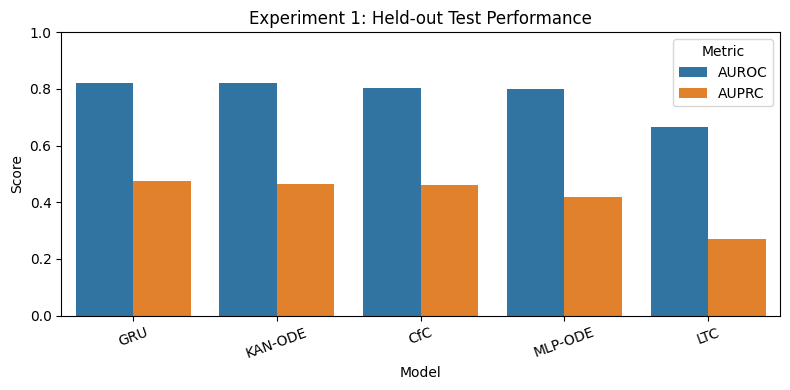

Saved: /content/kan_ode_icu/figures/experiment1_metrics.png


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

FIG_DIR = Path("/content/kan_ode_icu/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Check columns
print(exp1.columns.tolist())

plot_df = exp1.melt(
    id_vars="Model",
    value_vars=["AUROC", "AUPRC"],
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(8, 4))
sns.barplot(
    data=plot_df,
    x="Model",
    y="Score",
    hue="Metric"
)

plt.ylim(0, 1)
plt.title("Experiment 1: Held-out Test Performance")
plt.ylabel("Score")
plt.xlabel("Model")
plt.xticks(rotation=20)
plt.tight_layout()

plot_path = FIG_DIR / "experiment1_metrics.png"
plt.savefig(plot_path, dpi=200, bbox_inches="tight")
plt.show()

print("Saved:", plot_path)

#### Experiment 1 Plot Interpretation

This plot compares the held-out test AUROC and AUPRC for the five evaluated models. GRU achieved the strongest overall discrimination, with the highest AUROC and AUPRC among the models. KAN-ODE performed very close to GRU, showing that the KAN-based continuous-time model was competitive on the ICU mortality prediction task. CfC also achieved similar performance, especially in AUPRC, indicating that gated continuous-time dynamics can work well for irregular clinical time series.

MLP-ODE achieved slightly lower AUPRC than GRU, KAN-ODE, and CfC, although its AUROC remained competitive. LTC had the weakest performance, with noticeably lower AUROC and AUPRC. Overall, the graph shows that GRU, KAN-ODE, and CfC were the strongest models for held-out discrimination, while LTC was less effective in this experiment.

### Experiment 1 Interpretation

GRU achieved the strongest held-out discrimination, with an AUROC of 0.823 and AUPRC of 0.474. KAN-ODE produced comparable performance using fewer parameters, but required substantially greater computation, averaging approximately 1,146 seconds per epoch. CfC provided a strong efficiency trade-off, approaching GRU and KAN-ODE performance with 4,936 parameters and approximately 44 seconds per epoch.

MLP-ODE achieved the lowest Brier score of 0.107, indicating the best probability calibration, although its discrimination was lower than GRU, KAN-ODE, and CfC. LTC performed substantially worse than the other approaches. Overall, these results show that the most expressive continuous-time model was not necessarily the most computationally practical, and that parameter count alone did not determine either predictive performance or runtime.

## Experiment 1 Write-Up: Headline Model Comparison

Experiment 1 compared GRU, MLP-ODE, KAN-ODE, LTC, and CfC models on the same ICU mortality prediction task. All models used the same processed dataset, leakage-free train/validation/test split, normalization procedure, positive-class-weighted binary cross-entropy loss, and evaluation metrics. The models were compared using AUROC, AUPRC, Brier score, parameter count, training time per epoch, and best validation epoch.

GRU achieved the strongest held-out discrimination, with AUROC 0.823 and AUPRC 0.474. KAN-ODE achieved comparable performance with AUROC 0.821 and AUPRC 0.464 while using fewer parameters than GRU, but it required substantially greater computation, averaging approximately 1,146 seconds per epoch. CfC also performed competitively, with AUROC 0.805 and AUPRC 0.462, while requiring less time than KAN-ODE. MLP-ODE achieved the lowest Brier score of 0.107, indicating the best probability calibration, although its discrimination was lower. LTC had the weakest overall performance.

Overall, Experiment 1 shows that the most expressive continuous-time model was not necessarily the most computationally practical. GRU and CfC provided strong accuracy-efficiency tradeoffs, KAN-ODE was competitive but slow, and MLP-ODE was strongest in calibration.

## Experiment 2 — Robustness to sampling irregularity
Experiment 2 evaluates how robust each trained model is when the ICU time-series records become increasingly sparse. This is important because real clinical data often contain missing measurements, irregular sampling, and variable observation frequency across patients. A model that performs well only when complete records are available may be less reliable in practical ICU settings.

In this experiment, the trained models from Experiment 1 are evaluated after retaining different fractions of each patient's observations: 100%, 75%, 50%, and 25%. For each random seed, the same timestamps are removed for every model so that the comparison is fair. After thinning the records, the time gaps and GRU hourly bins are rebuilt from the thinned data.

No model is retrained during this experiment. The goal is to test zero-shot robustness: how well each already-trained model handles missing or reduced observations at test time. Performance is compared using AUROC, AUPRC, and Brier score across the different retention levels.

In [ ]:
DROP_RATES = [0.0, 0.25, 0.50, 0.75]

In [ ]:
print("Models:", list(trained.keys()))
print("Test patients:", len(test_idx))

Models: ['GRU', 'MLP-ODE']
Test patients: 600


In [ ]:
kan_model = NeuralODEClassifier(
    hidden_dim=8,
    family="kan",
    kan_width=[9, 12, 8],
    grid=3
).to(DEVICE)

kan_model.load_state_dict(
    torch.load(
        RESULTS_DIR / "KAN-ODE_best.pt",
        map_location=DEVICE
    )
)

kan_model.eval()
trained["KAN-ODE"] = kan_model

print("Models:", list(trained.keys()))

checkpoint directory created: ./model
saving model version 0.0
Models: ['GRU', 'MLP-ODE', 'KAN-ODE']


In [ ]:
for filename in [
    "LTC_best.pt",
    "CfC_best.pt"
]:
    path = RESULTS_DIR / filename
    print(filename, "exists:", path.exists())

LTC_best.pt exists: False
CfC_best.pt exists: False


In [ ]:
ltc_model = LiquidRiskModel(
    units=32,
    cell="ltc"
).double()

print("LTC parameters:", count_params(ltc_model))

ltc_model, ltc_history = fit_model(
    model=ltc_model,
    train_loader=train_loader,
    val_loader=val_loader,
    name="LTC",
    epochs=20,
    lr=1e-4,
    patience=5
)

trained["LTC"] = ltc_model
histories["LTC"] = ltc_history

ltc_history.to_csv(
    RESULTS_DIR / "LTC_history.csv",
    index=False
)

print("LTC finished.")
print("LTC checkpoint exists:", (RESULTS_DIR / "LTC_best.pt").exists())

LTC parameters: 7314
LTC {'epoch': 1, 'loss': 1.2013221611662315, 'val_auprc': np.float64(0.12083491684528179), 'val_auroc': np.float64(0.4602782503320827), 'val_brier': np.float64(0.267557546341121), 'sec': 48.71856410700093, 'peak_gpu_mb': 608.6220703125}
LTC {'epoch': 2, 'loss': 1.197501841443118, 'val_auprc': np.float64(0.1240444297319057), 'val_auroc': np.float64(0.4754025774276992), 'val_brier': np.float64(0.2632442630565963), 'sec': 46.31976362500063, 'peak_gpu_mb': 606.69873046875}
LTC {'epoch': 3, 'loss': 1.195854909993063, 'val_auprc': np.float64(0.1287498373440082), 'val_auroc': np.float64(0.49348651860828224), 'val_brier': np.float64(0.2595525545279099), 'sec': 46.490268481000385, 'peak_gpu_mb': 606.69873046875}
LTC {'epoch': 4, 'loss': 1.1931152419784985, 'val_auprc': np.float64(0.13442678826959947), 'val_auroc': np.float64(0.5113607233576472), 'val_brier': np.float64(0.2566279420996169), 'sec': 45.90546311300022, 'peak_gpu_mb': 606.69873046875}
LTC {'epoch': 5, 'loss': 1.

In [ ]:
cfc_model = LiquidRiskModel(
    units=32,
    cell="cfc"
)

print("CfC parameters:", count_params(cfc_model))

cfc_model, cfc_history = fit_model(
    model=cfc_model,
    train_loader=train_loader,
    val_loader=val_loader,
    name="CfC",
    epochs=20,
    lr=1e-3,
    patience=5
)

trained["CfC"] = cfc_model
histories["CfC"] = cfc_history

cfc_history.to_csv(
    RESULTS_DIR / "CfC_history.csv",
    index=False
)

print("CfC finished.")
print("CfC checkpoint exists:", (RESULTS_DIR / "CfC_best.pt").exists())

CfC parameters: 4936
CfC {'epoch': 1, 'loss': 1.137127403508533, 'val_auprc': np.float64(0.30290878178073916), 'val_auroc': np.float64(0.6923399594509567), 'val_brier': np.float64(0.18979094371312225), 'sec': 48.967587487000856, 'peak_gpu_mb': 34.95654296875}
CfC {'epoch': 2, 'loss': 1.0894918898967179, 'val_auprc': np.float64(0.3578131924245322), 'val_auroc': np.float64(0.754212206660297), 'val_brier': np.float64(0.17657093579796537), 'sec': 43.13168673600012, 'peak_gpu_mb': 34.95654296875}
CfC {'epoch': 3, 'loss': 1.0386480377479033, 'val_auprc': np.float64(0.38371634131133575), 'val_auroc': np.float64(0.775325674069586), 'val_brier': np.float64(0.19406683663480162), 'sec': 43.03434005899908, 'peak_gpu_mb': 34.95654296875}
CfC {'epoch': 4, 'loss': 1.01576094803485, 'val_auprc': np.float64(0.3829170590821662), 'val_auroc': np.float64(0.7858357996784042), 'val_brier': np.float64(0.18629028326448605), 'sec': 44.21841914600009, 'peak_gpu_mb': 34.95654296875}
CfC {'epoch': 5, 'loss': 1.01

In [ ]:
print("Models currently loaded:", list(trained.keys()))

print(
    "LTC checkpoint:",
    (RESULTS_DIR / "LTC_best.pt").exists()
)

print(
    "CfC checkpoint:",
    (RESULTS_DIR / "CfC_best.pt").exists()
)

Models currently loaded: ['GRU', 'MLP-ODE', 'KAN-ODE', 'LTC', 'CfC']
LTC checkpoint: True
CfC checkpoint: True


In [ ]:
def thin_record(record, retained_fraction, rng):
    n_times = len(record["times"])

    # Return an independent copy when no thinning is required.
    if retained_fraction >= 1.0 or n_times <= 2:
        return {
            key: value.copy() if isinstance(value, np.ndarray) else value
            for key, value in record.items()
        }

    keep_count = max(
        2,
        int(round(n_times * retained_fraction))
    )

    # Preserve the first and final timestamps.
    middle_indices = np.arange(1, n_times - 1)

    selected_middle = rng.choice(
        middle_indices,
        size=min(
            max(keep_count - 2, 0),
            len(middle_indices)
        ),
        replace=False
    )

    kept_indices = np.sort(
        np.concatenate((
            np.array([0]),
            selected_middle,
            np.array([n_times - 1])
        ))
    )

    thinned_record = {
        key: value.copy() if isinstance(value, np.ndarray) else value
        for key, value in record.items()
    }

    for key in [
        "times",
        "values",
        "mask",
        "delta_var",
        "delta_step"
    ]:
        thinned_record[key] = thinned_record[key][kept_indices]

    # Recalculate elapsed time after timestamps are removed.
    new_times = thinned_record["times"]

    thinned_record["delta_step"] = np.diff(
        np.concatenate((
            np.array([new_times[0]]),
            new_times
        ))
    ).astype(np.float32)

    thinned_record["delta_step"][0] = max(
        float(new_times[0]),
        0.0
    )

    return thinned_record


print("thin_record function defined successfully.")

thin_record function defined successfully.


In [ ]:
fractions = [1.0, 0.75, 0.50, 0.25]
drop_seeds = [11, 22, 33, 44, 55]

robust_rows = []
base_test = [records[i] for i in test_idx]

for fraction in fractions:
    for seed in drop_seeds:
        rng = np.random.default_rng(seed)

        thinned_records = [
            thin_record(record, fraction, rng)
            for record in base_test
        ]

        thinned_loader = DataLoader(
            ICURecords(
                thinned_records,
                np.arange(len(thinned_records))
            ),
            batch_size=BATCH_SIZE,
            shuffle=False,
            collate_fn=collate_irregular
        )

        for model_name, model in trained.items():
            metrics = evaluate(
                model,
                thinned_loader
            )

            robust_rows.append({
                "Model": model_name,
                "Retained": int(fraction * 100),
                "Seed": seed,
                **metrics
            })

            print(
                model_name,
                f"retained={int(fraction * 100)}%",
                f"seed={seed}",
                metrics
            )

robust = pd.DataFrame(robust_rows)

robust.to_csv(
    RESULTS_DIR / "experiment2_robustness.csv",
    index=False
)

display(
    robust.groupby(
        ["Model", "Retained"]
    )[["auroc", "auprc", "brier"]]
    .agg(["mean", "std"])
    .round(4)
)

GRU retained=100% seed=11 {'auroc': np.float64(0.8225163710936589), 'auprc': np.float64(0.47385057848977513), 'brier': np.float64(0.17429028388213458)}
MLP-ODE retained=100% seed=11 {'auroc': np.float64(0.7999114446179301), 'auprc': np.float64(0.41949927472980764), 'brier': np.float64(0.1069010935156345)}
KAN-ODE retained=100% seed=11 {'auroc': np.float64(0.8206753513085222), 'auprc': np.float64(0.46359096091067326), 'brier': np.float64(0.27732907430545095)}
LTC retained=100% seed=11 {'auroc': np.float64(0.6657267367341707), 'auprc': np.float64(0.2696329957088518), 'brier': np.float64(0.2413290795407994)}
CfC retained=100% seed=11 {'auroc': np.float64(0.8047353825359466), 'auprc': np.float64(0.46225952815020876), 'brier': np.float64(0.17539541674218223)}
GRU retained=100% seed=22 {'auroc': np.float64(0.8225163710936589), 'auprc': np.float64(0.47385057848977513), 'brier': np.float64(0.17429028388213458)}
MLP-ODE retained=100% seed=22 {'auroc': np.float64(0.7999114446179301), 'auprc': np

auroc           auprc           brier        
                    mean     std    mean     std    mean     std
Model   Retained                                                
CfC     25        0.7901  0.0084  0.4220  0.0284  0.1894  0.0030
        50        0.8075  0.0055  0.4427  0.0212  0.1774  0.0026
        75        0.8024  0.0059  0.4597  0.0120  0.1753  0.0022
        100       0.8047  0.0000  0.4623  0.0000  0.1754  0.0000
GRU     25        0.7953  0.0039  0.4180  0.0083  0.2169  0.0021
        50        0.8214  0.0121  0.4750  0.0214  0.1897  0.0042
        75        0.8237  0.0043  0.4842  0.0186  0.1798  0.0024
        100       0.8225  0.0000  0.4739  0.0000  0.1743  0.0000
KAN-ODE 25        0.8113  0.0073  0.4411  0.0256  0.2735  0.0046
        50        0.8192  0.0058  0.4640  0.0185  0.2772  0.0018
        75        0.8191  0.0026  0.4507  0.0087  0.2773  0.0008
        100       0.8207  0.0000  0.4636  0.0000  0.2773  0.0000
LTC     25        0.6479  0.0178  0.2493  0.0321  0.2433  0.0006
        50        0.6564  0.0090  0.2579  0.0118  0.2427  0.0002
        75        0.6651  0.0027  0.2723  0.0109  0.2419  0.0002
        100       0.6657  0.0000  0.2696  0.0000  0.2413  0.0000
MLP-ODE 25        0.7902  0.0102  0.3998  0.0319  0.1125  0.0024
        50        0.7994  0.0058  0.4222  0.0185  0.1077  0.0018
        75        0.7999  0.0030  0.4184  0.0062  0.1073  0.0010
        100       0.7999  0.0000  0.4195  0.0000  0.1069  0.0000

Experiment 2 evaluated zero-shot robustness after retaining 100%, 75%, 50%, or 25% of patient observations without retraining. KAN-ODE was the most robust discriminative model under severe observation loss. Its mean AUROC decreased only from 0.821 with complete records to 0.811 at 25% retention, while AUPRC decreased from 0.464 to 0.441. GRU achieved the strongest complete-record AUPRC of 0.474 but declined to 0.418 at 25% retention. CfC also remained reasonably robust, whereas LTC produced the weakest AUROC and AUPRC across all retention levels. MLP-ODE consistently achieved the lowest Brier score, indicating substantially better-calibrated probabilities despite lower AUPRC than KAN-ODE and GRU. Minor improvements at some intermediate retention levels likely reflect sampling variation across the five random thinning seeds. Overall, KAN-ODE offered the strongest resistance to missing observations, while MLP-ODE offered the best probability calibration.

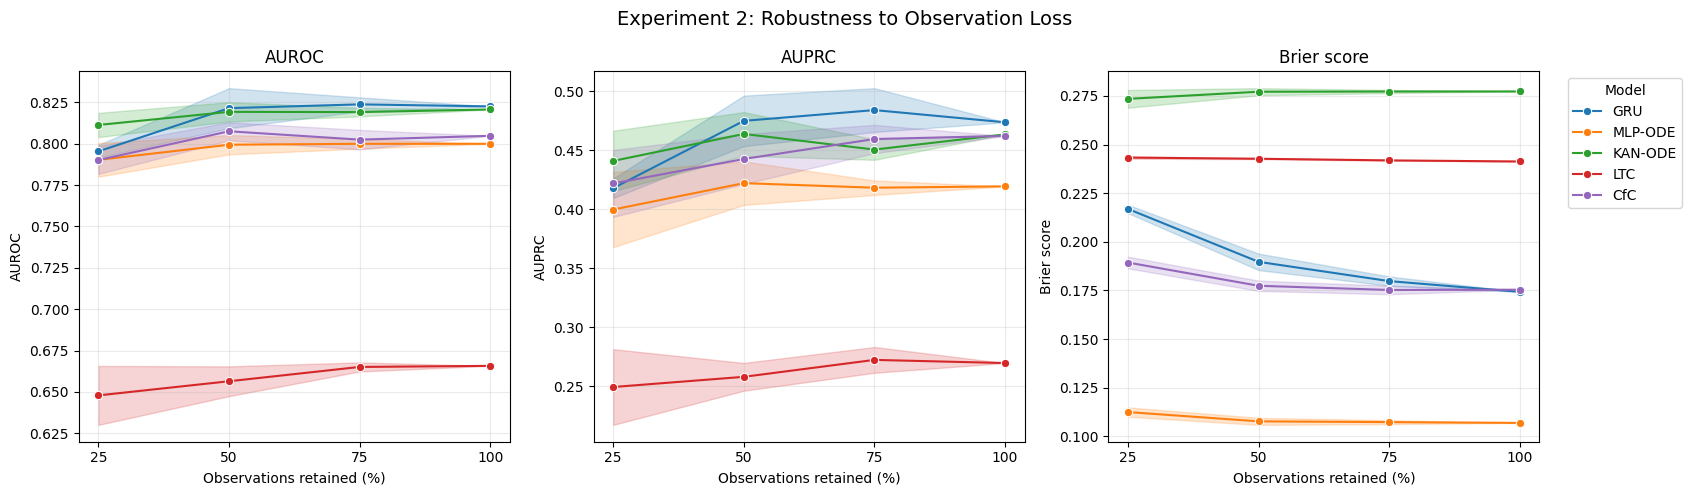

In [ ]:
fig, axes = plt.subplots(
    1,
    3,
    figsize=(17, 5)
)

metrics = [
    ("auroc", "AUROC"),
    ("auprc", "AUPRC"),
    ("brier", "Brier score")
]

for axis, (metric, title) in zip(axes, metrics):
    sns.lineplot(
        data=robust,
        x="Retained",
        y=metric,
        hue="Model",
        marker="o",
        errorbar="sd",
        ax=axis
    )

    axis.set_title(title)
    axis.set_xlabel("Observations retained (%)")
    axis.set_ylabel(title)
    axis.set_xticks([25, 50, 75, 100])
    axis.grid(alpha=0.25)

# Keep the legend only in the last panel.
axes[0].get_legend().remove()
axes[1].get_legend().remove()
axes[2].legend(
    title="Model",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.suptitle(
    "Experiment 2: Robustness to Observation Loss",
    fontsize=14
)

plt.tight_layout()

plt.savefig(
    FIG_DIR / "experiment2_robustness.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

In [ ]:
from google.colab import drive
from pathlib import Path
import shutil
import json
import torch

# Mount Drive if it is not already mounted.
drive.mount("/content/drive")

SAVE_DIR = Path(
    "/content/drive/MyDrive/KAN_ODE_ICU_Assignment/final_results"
)

CHECKPOINT_DIR = SAVE_DIR / "checkpoints"
TABLE_DIR = SAVE_DIR / "tables"
FIGURE_DIR = SAVE_DIR / "figures"
HISTORY_DIR = SAVE_DIR / "histories"

for folder in [
    SAVE_DIR,
    CHECKPOINT_DIR,
    TABLE_DIR,
    FIGURE_DIR,
    HISTORY_DIR
]:
    folder.mkdir(parents=True, exist_ok=True)


# 1. Save each model checkpoint separately


for model_name, model in trained.items():
    checkpoint_path = (
        CHECKPOINT_DIR /
        f"{model_name.replace('/', '_')}_best.pt"
    )

    torch.save(
        model.state_dict(),
        checkpoint_path
    )

    print("Saved model:", checkpoint_path)



# 2. Save all five models in one combined file


torch.save(
    {
        model_name: model.state_dict()
        for model_name, model in trained.items()
    },
    SAVE_DIR / "experiment1_all_trained_models.pt"
)

# 3. Save Experiment 2 raw results

robust.to_csv(
    TABLE_DIR / "experiment2_robustness_raw.csv",
    index=False
)


# 4. Save clean Experiment 2 summary table

experiment2_summary = (
    robust
    .groupby(["Model", "Retained"])
    .agg(
        AUROC_mean=("auroc", "mean"),
        AUROC_std=("auroc", "std"),
        AUPRC_mean=("auprc", "mean"),
        AUPRC_std=("auprc", "std"),
        Brier_mean=("brier", "mean"),
        Brier_std=("brier", "std")
    )
    .reset_index()
)

experiment2_summary.to_csv(
    TABLE_DIR / "experiment2_robustness_summary.csv",
    index=False
)

display(experiment2_summary.round(4))


# 5. Save training histories

for model_name, history in histories.items():
    if isinstance(history, pd.DataFrame):
        history.to_csv(
            HISTORY_DIR /
            f"{model_name.replace('/', '_')}_history.csv",
            index=False
        )

# 6. Copy Experiment 2 plot


plot_source = FIG_DIR / "experiment2_robustness.png"

if plot_source.exists():
    shutil.copy2(
        plot_source,
        FIGURE_DIR / "experiment2_robustness.png"
    )
    print("Experiment 2 plot saved.")
else:
    print("Plot not found. Run the plotting cell first.")


# 7. Save architecture and experiment configuration


configuration = {
    "FAST_MODE": False,
    "total_patients": len(records),
    "train_patients": len(train_idx),
    "validation_patients": len(val_idx),
    "test_patients": len(test_idx),
    "variables": VARS,
    "retained_fractions": [
        1.0,
        0.75,
        0.50,
        0.25
    ],
    "random_seeds": [
        11,
        22,
        33,
        44,
        55
    ],
    "model_configuration": {
        "GRU": {
            "hidden": 32
        },
        "MLP-ODE": {
            "hidden_dim": 20,
            "width": 64
        },
        "KAN-ODE": {
            "hidden_dim": 8,
            "kan_width": [9, 12, 8],
            "grid": 3
        },
        "LTC": {
            "units": 32,
            "dtype": "float64"
        },
        "CfC": {
            "units": 32,
            "dtype": "float32"
        }
    }
}

with open(
    SAVE_DIR / "experiment_configuration.json",
    "w"
) as file:
    json.dump(
        configuration,
        file,
        indent=2
    )


# 8. Verify everything saved

print("\nSaved files:")

for saved_file in sorted(SAVE_DIR.rglob("*")):
    if saved_file.is_file():
        print(saved_file)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Saved model: /content/drive/MyDrive/KAN_ODE_ICU_Assignment/final_results/checkpoints/GRU_best.pt
Saved model: /content/drive/MyDrive/KAN_ODE_ICU_Assignment/final_results/checkpoints/MLP-ODE_best.pt
Saved model: /content/drive/MyDrive/KAN_ODE_ICU_Assignment/final_results/checkpoints/KAN-ODE_best.pt
Saved model: /content/drive/MyDrive/KAN_ODE_ICU_Assignment/final_results/checkpoints/LTC_best.pt
Saved model: /content/drive/MyDrive/KAN_ODE_ICU_Assignment/final_results/checkpoints/CfC_best.pt


,Model,Retained,AUROC_mean,AUROC_std,AUPRC_mean,AUPRC_std,Brier_mean,Brier_std
0,CfC,25,0.7901,0.0084,0.4220,0.0284,0.1894,0.0030
1,CfC,50,0.8075,0.0055,0.4427,0.0212,0.1774,0.0026
2,CfC,75,0.8024,0.0059,0.4597,0.0120,0.1753,0.0022
3,CfC,100,0.8047,0.0000,0.4623,0.0000,0.1754,0.0000
4,GRU,25,0.7953,0.0039,0.4180,0.0083,0.2169,0.0021
5,GRU,50,0.8214,0.0121,0.4750,0.0214,0.1897,0.0042
6,GRU,75,0.8237,0.0043,0.4842,0.0186,0.1798,0.0024
7,GRU,100,0.8225,0.0000,0.4739,0.0000,0.1743,0.0000
8,KAN-ODE,25,0.8113,0.0073,0.4411,0.0256,0.2735,0.0046
9,KAN-ODE,50,0.8192,0.0058,0.4640,0.0185,0.2772,0.0018


Experiment 2 plot saved.

Saved files:
/content/drive/MyDrive/KAN_ODE_ICU_Assignment/final_results/checkpoints/CfC_best.pt
/content/drive/MyDrive/KAN_ODE_ICU_Assignment/final_results/checkpoints/GRU_best.pt
/content/drive/MyDrive/KAN_ODE_ICU_Assignment/final_results/checkpoints/KAN-ODE_best.pt
/content/drive/MyDrive/KAN_ODE_ICU_Assignment/final_results/checkpoints/LTC_best.pt
/content/drive/MyDrive/KAN_ODE_ICU_Assignment/final_results/checkpoints/MLP-ODE_best.pt
/content/drive/MyDrive/KAN_ODE_ICU_Assignment/final_results/experiment1_all_trained_models.pt
/content/drive/MyDrive/KAN_ODE_ICU_Assignment/final_results/experiment_configuration.json
/content/drive/MyDrive/KAN_ODE_ICU_Assignment/final_results/figures/experiment2_robustness.png
/content/drive/MyDrive/KAN_ODE_ICU_Assignment/final_results/histories/CfC_history.csv
/content/drive/MyDrive/KAN_ODE_ICU_Assignment/final_results/histories/GRU_history.csv
/content/drive/MyDrive/KAN_ODE_ICU_Assignment/final_results/histories/LTC_history.

In [ ]:
# Add the separately preserved KAN history.
if "KAN-ODE" not in histories and "kan_history" in globals():
    histories["KAN-ODE"] = kan_history

# Save all available histories again.
for model_name, history in histories.items():
    if isinstance(history, pd.DataFrame):
        history.to_csv(
            HISTORY_DIR /
            f"{model_name.replace('/', '_')}_history.csv",
            index=False
        )


# Create the final Experiment 1 table.
experiment1_rows = []

for model_name, model in trained.items():
    test_metrics = evaluate(
        model,
        test_loader
    )

    history = histories.get(model_name)

    if isinstance(history, pd.DataFrame):
        best_epoch = int(
            history.loc[
                history["val_auprc"].idxmax(),
                "epoch"
            ]
        )

        seconds_per_epoch = float(
            history["sec"].mean()
        )
    else:
        best_epoch = np.nan
        seconds_per_epoch = np.nan

    experiment1_rows.append({
        "Model": model_name,
        "AUROC": test_metrics["auroc"],
        "AUPRC": test_metrics["auprc"],
        "Brier": test_metrics["brier"],
        "Parameters": count_params(model),
        "Seconds_per_epoch": seconds_per_epoch,
        "Best_epoch": best_epoch
    })

experiment1_final = (
    pd.DataFrame(experiment1_rows)
    .sort_values("AUPRC", ascending=False)
    .reset_index(drop=True)
)

display(experiment1_final.round(4))

experiment1_final.to_csv(
    TABLE_DIR / "experiment1_final_results.csv",
    index=False
)

print("Final Experiment 1 table saved.")
print(
    "KAN history saved:",
    (HISTORY_DIR / "KAN-ODE_history.csv").exists()
)

,Model,AUROC,AUPRC,Brier,Parameters,Seconds_per_epoch,Best_epoch
0,GRU,0.8225,0.4739,0.1743,5601,3.6515,12
1,KAN-ODE,0.8207,0.4636,0.2773,4641,1145.9844,5
2,CfC,0.8047,0.4623,0.1754,4936,43.6911,11
3,MLP-ODE,0.7999,0.4195,0.1069,9853,25.5993,11
4,LTC,0.6657,0.2696,0.2413,7314,45.9548,20


Final Experiment 1 table saved.
KAN history saved: True


### Experiment 2 interpretation

Experiment 2 evaluated zero-shot robustness after retaining 100%, 75%,
50%, or 25% of patient observations without retraining. KAN-ODE was the
most robust discriminative model under severe observation loss. Its mean
AUROC decreased only from 0.821 with complete records to 0.811 at 25%
retention, while AUPRC decreased from 0.464 to 0.441. GRU achieved the
strongest complete-record AUPRC of 0.474 but declined to 0.418 at 25%
retention. CfC also remained reasonably robust, whereas LTC produced the
weakest AUROC and AUPRC across all retention levels. MLP-ODE consistently
achieved the lowest Brier score, indicating better-calibrated probabilities
despite lower AUPRC than KAN-ODE and GRU. Minor improvements at some
intermediate retention levels likely reflect sampling variation across the
five random thinning seeds. Overall, KAN-ODE offered the strongest
resistance to missing observations, while MLP-ODE provided the best
probability calibration.

## Experiment 2 Write-Up: Robustness to Observation Loss

Experiment 2 evaluated how robust each trained model was when ICU time-series records became increasingly sparse. This is important because real clinical data often contain missing measurements, irregular sampling, and variable observation frequency across patients. The trained models from Experiment 1 were evaluated after retaining 100%, 75%, 50%, and 25% of each patient's observations.

For each random seed, the same timestamps were removed for every model so that the comparison was fair. After thinning the records, time gaps and GRU hourly bins were rebuilt from the thinned data. No model was retrained during this experiment, so the results measure zero-shot robustness to observation loss.

KAN-ODE showed strong robustness under severe observation loss. Its AUROC decreased only slightly from about 0.821 with full observations to about 0.811 when only 25% of observations were retained. GRU and CfC also remained competitive, although GRU showed a larger AUPRC decline at the lowest retention level. LTC remained the weakest model. Overall, Experiment 2 suggests that continuous-time latent dynamics can help preserve performance when observations become sparse, but strong recurrent baselines can also remain effective when masking and time information are handled carefully.

# 13. Experiment 3 — Interpretability probe (KAN-ODE only, with a written comparison)

Experiment 3 investigates whether the KAN component of the trained KAN-ODE model provides useful interpretability beyond predictive performance. Unlike the baseline comparison in Experiment 1, this experiment focuses on the internal KAN vector field learned inside the neural ODE. The goal is to examine which KAN inputs influence the latent dynamics, how the learned vector field responds to controlled input changes, whether weak KAN connections can be pruned, and whether the learned dynamics can be approximated symbolically.

The KAN-ODE inputs in this experiment are not raw clinical variables. They are the learned latent-state dimensions produced by the encoder, together with normalized time. Therefore, latent dimensions should not be directly renamed as clinical variables without a separate attribution analysis linking them back to the original ICU measurements.

Plots are generated before pruning and symbolic fitting so that the original learned KAN structure is preserved for comparison. Since `pykan` symbolic routines can vary across package versions, the symbolic fitting cells are treated as diagnostic and include error handling where needed. The final interpretation focuses on input importance, controlled response curves, pruning behavior, and the complexity of the extracted symbolic expressions.

In [ ]:
kan_model = trained["KAN-ODE"]
kan_model.eval()

kan_core = kan_model.odefunc.kan

print("KAN model loaded:", type(kan_model).__name__)
print("KAN core loaded:", type(kan_core).__name__)
print("KAN parameters:", count_params(kan_model))

KAN model loaded: NeuralODEClassifier
KAN core loaded: MultKAN
KAN parameters: 4641


In [ ]:
kan_inputs = []

kan_model.eval()

with torch.no_grad():
    for batch_number, batch in enumerate(train_loader):
        batch = to_device(batch)

        latent_state = kan_model.encoder(
            values=batch["values"],
            mask=batch["mask"],
            times=batch["times"],
            valid=batch["valid"]
        )

        # KAN-ODE vector field input consists of:
        # 8 latent variables + 1 normalized-time variable.
        normalized_time = torch.ones(
            latent_state.shape[0],
            1,
            device=latent_state.device,
            dtype=latent_state.dtype
        )

        kan_input = torch.cat(
            [latent_state, normalized_time],
            dim=1
        )

        kan_inputs.append(
            kan_input.detach().cpu()
        )

        # Use ten training batches for the interpretability probe.
        if batch_number >= 9:
            break

kan_inputs = torch.cat(
    kan_inputs,
    dim=0
).to(DEVICE)

print("Interpretability input shape:", kan_inputs.shape)
print(
    "All values finite:",
    torch.isfinite(kan_inputs).all().item()
)
print(
    "Input range:",
    kan_inputs.min().item(),
    kan_inputs.max().item()
)

Interpretability input shape: torch.Size([320, 9])
All values finite: True
Input range: -1.1682690382003784 1.4226512908935547


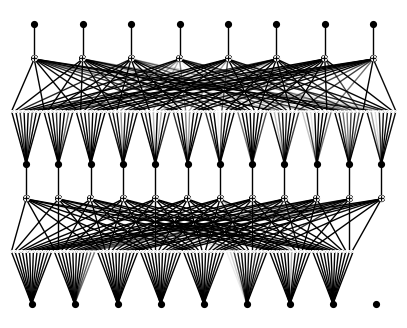

Saved: /content/kan_ode_icu/figures/experiment3_kan_before_pruning.png


In [ ]:
# Run a forward pass so pykan stores activations for plotting.
with torch.no_grad():
    _ = kan_core(kan_inputs)

# Plot the unpruned KAN.
kan_core.plot(beta=100)

plt.savefig(
    FIG_DIR / "experiment3_kan_before_pruning.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print(
    "Saved:",
    FIG_DIR / "experiment3_kan_before_pruning.png"
)

In [ ]:
EXP3_DRIVE_DIR = Path(
    "/content/drive/MyDrive/"
    "KAN_ODE_ICU_Assignment/final_results/experiment3"
)

EXP3_DRIVE_DIR.mkdir(
    parents=True,
    exist_ok=True
)

shutil.copy2(
    FIG_DIR / "experiment3_kan_before_pruning.png",
    EXP3_DRIVE_DIR / "experiment3_kan_before_pruning.png"
)

print("Pre-pruning figure saved to Drive.")

Pre-pruning figure saved to Drive.


In [ ]:

# Experiment 3: permutation importance of KAN inputs


input_names = [
    "Latent 1",
    "Latent 2",
    "Latent 3",
    "Latent 4",
    "Latent 5",
    "Latent 6",
    "Latent 7",
    "Latent 8",
    "Normalized time"
]

kan_core.eval()

with torch.no_grad():
    baseline_output = kan_core(
        kan_inputs
    ).detach()

importance_scores = []

generator = torch.Generator(
    device=kan_inputs.device
)
generator.manual_seed(SEED)

for input_index, input_name in enumerate(input_names):
    permuted_inputs = kan_inputs.clone()

    permutation = torch.randperm(
        len(permuted_inputs),
        generator=generator,
        device=permuted_inputs.device
    )

    permuted_inputs[:, input_index] = (
        permuted_inputs[
            permutation,
            input_index
        ]
    )

    with torch.no_grad():
        permuted_output = kan_core(
            permuted_inputs
        ).detach()

    importance = torch.mean(
        torch.abs(
            baseline_output -
            permuted_output
        )
    ).item()

    importance_scores.append({
        "Input": input_name,
        "Input_index": input_index,
        "Importance": importance
    })

importance_df = (
    pd.DataFrame(importance_scores)
    .sort_values(
        "Importance",
        ascending=False
    )
    .reset_index(drop=True)
)

display(importance_df.round(6))

top_two_inputs = importance_df.head(2)

print("\nTwo most influential inputs:")
display(top_two_inputs)

,Input,Input_index,Importance
0,Latent 4,3,0.004874
1,Latent 8,7,0.003578
2,Latent 5,4,0.002743
3,Latent 1,0,0.002724
4,Latent 7,6,0.002703
5,Latent 3,2,0.002554
6,Latent 6,5,0.001710
7,Latent 2,1,0.001171
8,Normalized time,8,0.000000



Two most influential inputs:


,Input,Input_index,Importance
0,Latent 4,3,0.004874
1,Latent 8,7,0.003578


In [ ]:
# Build KAN inputs across the full normalized time range

time_grid = torch.tensor(
    [0.00, 0.25, 0.50, 0.75, 1.00],
    device=DEVICE,
    dtype=kan_inputs.dtype
)

latent_inputs = kan_inputs[:, :8]

expanded_latents = latent_inputs.repeat_interleave(
    len(time_grid),
    dim=0
)

expanded_times = time_grid.repeat(
    len(latent_inputs)
).unsqueeze(1)

kan_inputs_timevarying = torch.cat(
    [
        expanded_latents,
        expanded_times
    ],
    dim=1
)

print(
    "Time-varying input shape:",
    kan_inputs_timevarying.shape
)

print(
    "Time values:",
    torch.unique(
        kan_inputs_timevarying[:, 8]
    )
)

Time-varying input shape: torch.Size([1600, 9])
Time values: tensor([0.0000, 0.2500, 0.5000, 0.7500, 1.0000], device='cuda:0')


In [ ]:
input_names = [
    "Latent 1",
    "Latent 2",
    "Latent 3",
    "Latent 4",
    "Latent 5",
    "Latent 6",
    "Latent 7",
    "Latent 8",
    "Normalized time"
]

kan_core.eval()

with torch.no_grad():
    baseline_output = kan_core(
        kan_inputs_timevarying
    ).detach()

generator = torch.Generator(
    device=DEVICE
)
generator.manual_seed(SEED)

importance_rows = []

for input_index, input_name in enumerate(input_names):
    permuted_inputs = kan_inputs_timevarying.clone()

    permutation = torch.randperm(
        len(permuted_inputs),
        generator=generator,
        device=DEVICE
    )

    permuted_inputs[:, input_index] = (
        permuted_inputs[
            permutation,
            input_index
        ]
    )

    with torch.no_grad():
        permuted_output = kan_core(
            permuted_inputs
        ).detach()

    importance = torch.mean(
        torch.abs(
            baseline_output -
            permuted_output
        )
    ).item()

    importance_rows.append({
        "Input": input_name,
        "Input_index": input_index,
        "Importance": importance
    })

importance_timevarying_df = (
    pd.DataFrame(importance_rows)
    .sort_values(
        "Importance",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    importance_timevarying_df.round(6)
)

print("\nFinal two most influential inputs:")
display(
    importance_timevarying_df.head(2)
)

,Input,Input_index,Importance
0,Normalized time,8,0.012551
1,Latent 4,3,0.004751
2,Latent 8,7,0.003461
3,Latent 7,6,0.002987
4,Latent 5,4,0.002772
5,Latent 3,2,0.002680
6,Latent 1,0,0.002607
7,Latent 6,5,0.001599
8,Latent 2,1,0.001157



Final two most influential inputs:


,Input,Input_index,Importance
0,Normalized time,8,0.012551
1,Latent 4,3,0.004751


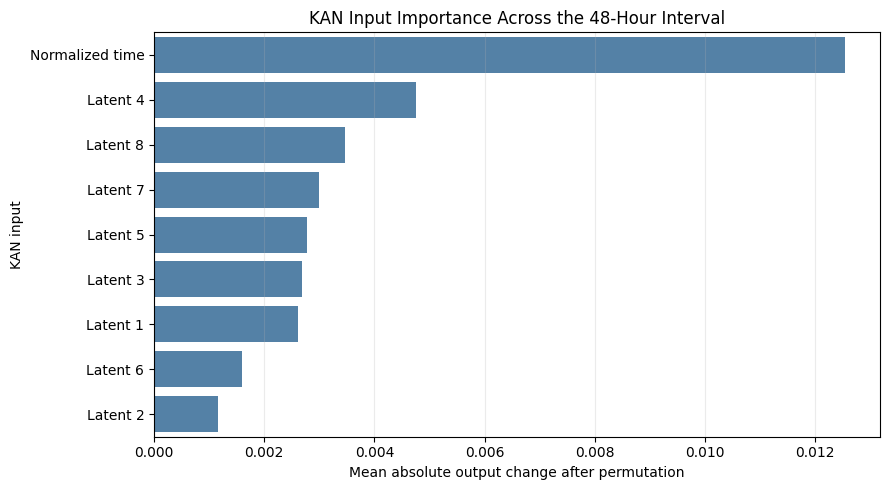

In [ ]:
importance_timevarying_df.to_csv(
    EXP3_DRIVE_DIR /
    "experiment3_input_importance_timevarying.csv",
    index=False
)

plt.figure(figsize=(9, 5))

sns.barplot(
    data=importance_timevarying_df,
    x="Importance",
    y="Input",
    color="steelblue"
)

plt.title(
    "KAN Input Importance Across the 48-Hour Interval"
)
plt.xlabel(
    "Mean absolute output change after permutation"
)
plt.ylabel("KAN input")
plt.grid(axis="x", alpha=0.25)
plt.tight_layout()

plt.savefig(
    EXP3_DRIVE_DIR /
    "experiment3_input_importance_timevarying.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

In [ ]:
# Controlled response curves for the top two KAN inputs

reference_input = torch.median(
    kan_inputs_timevarying,
    dim=0
).values

response_rows = []

top_inputs = [
    {
        "name": "Normalized time",
        "index": 8,
        "minimum": 0.0,
        "maximum": 1.0
    },
    {
        "name": "Latent 4",
        "index": 3,
        "minimum": torch.quantile(
            kan_inputs_timevarying[:, 3],
            0.01
        ).item(),
        "maximum": torch.quantile(
            kan_inputs_timevarying[:, 3],
            0.99
        ).item()
    }
]

for input_information in top_inputs:
    sweep_values = torch.linspace(
        input_information["minimum"],
        input_information["maximum"],
        100,
        device=DEVICE,
        dtype=kan_inputs_timevarying.dtype
    )

    controlled_inputs = (
        reference_input
        .unsqueeze(0)
        .repeat(100, 1)
    )

    controlled_inputs[
        :,
        input_information["index"]
    ] = sweep_values

    with torch.no_grad():
        vector_field_output = kan_core(
            controlled_inputs
        ).detach()

    # Overall magnitude of the eight-dimensional derivative.
    response_magnitude = torch.linalg.vector_norm(
        vector_field_output,
        ord=2,
        dim=1
    )

    # Signed average derivative across latent dimensions.
    response_signed_mean = vector_field_output.mean(
        dim=1
    )

    for x_value, magnitude, signed_mean in zip(
        sweep_values.cpu().numpy(),
        response_magnitude.cpu().numpy(),
        response_signed_mean.cpu().numpy()
    ):
        response_rows.append({
            "Input": input_information["name"],
            "Input_value": float(x_value),
            "Vector_field_magnitude": float(magnitude),
            "Mean_signed_derivative": float(signed_mean)
        })

response_df = pd.DataFrame(response_rows)

display(response_df.head())

,Input,Input_value,Vector_field_magnitude,Mean_signed_derivative
0,Normalized time,0.000000,0.100241,-0.021016
1,Normalized time,0.010101,0.100255,-0.020970
2,Normalized time,0.020202,0.100270,-0.020921
3,Normalized time,0.030303,0.100287,-0.020869
4,Normalized time,0.040404,0.100306,-0.020815


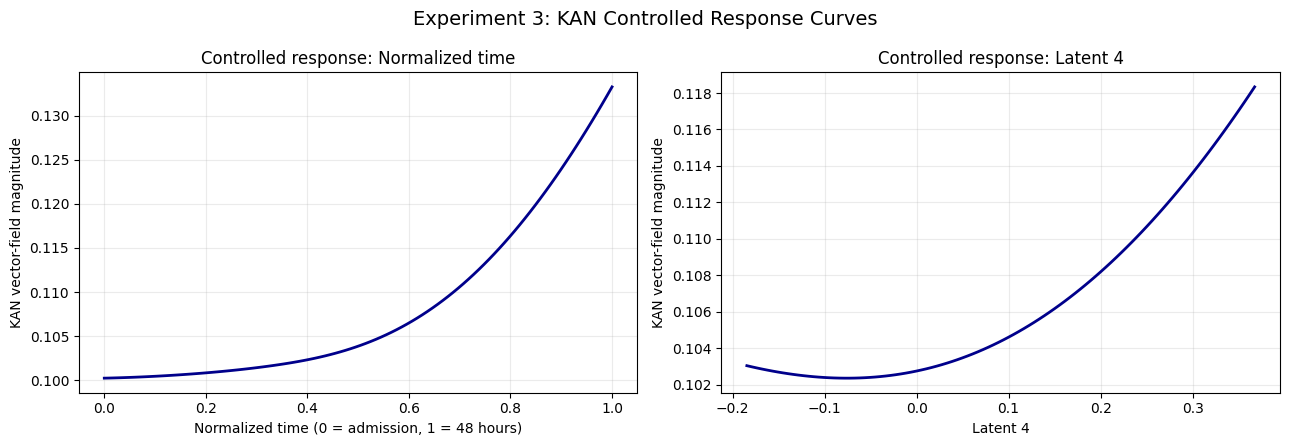

Controlled response curves and values saved.


In [ ]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(13, 4.5)
)

for axis, input_name in zip(
    axes,
    ["Normalized time", "Latent 4"]
):
    subset = response_df[
        response_df["Input"] == input_name
    ]

    axis.plot(
        subset["Input_value"],
        subset["Vector_field_magnitude"],
        linewidth=2,
        color="darkblue"
    )

    axis.set_title(
        f"Controlled response: {input_name}"
    )

    axis.set_xlabel(input_name)
    axis.set_ylabel(
        "KAN vector-field magnitude"
    )
    axis.grid(alpha=0.25)

axes[0].set_xlabel(
    "Normalized time (0 = admission, 1 = 48 hours)"
)

plt.suptitle(
    "Experiment 3: KAN Controlled Response Curves",
    fontsize=14
)

plt.tight_layout()

response_plot_path = (
    EXP3_DRIVE_DIR /
    "experiment3_controlled_response_curves.png"
)

plt.savefig(
    response_plot_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

response_df.to_csv(
    EXP3_DRIVE_DIR /
    "experiment3_controlled_response_values.csv",
    index=False
)

print("Controlled response curves and values saved.")

In [ ]:

# Create an independent KAN copy for pruning


kan_core_for_pruning = KAN(
    width=[9, 12, 8],
    grid=3,
    k=3,
    seed=SEED
).to(DEVICE)

kan_core_for_pruning.load_state_dict(
    kan_core.state_dict()
)

kan_core_for_pruning.eval()

# Populate activation statistics required for pruning.
with torch.no_grad():
    original_output = kan_core_for_pruning(
        kan_inputs_timevarying
    ).detach()

original_parameter_count = count_params(
    kan_core_for_pruning
)

print(
    "Original KAN-core parameters:",
    original_parameter_count
)

checkpoint directory created: ./model
saving model version 0.0
Original KAN-core parameters: 2448


In [ ]:

# Prune weak KAN nodes and edges


try:
    pruned_kan_core = kan_core_for_pruning.prune(
        node_th=1e-2,
        edge_th=3e-2
    )

    pruned_kan_core = pruned_kan_core.to(
        DEVICE
    )

    pruning_successful = True
    print("Pruning completed successfully.")

except Exception as error:
    pruning_successful = False
    pruned_kan_core = None

    print(
        "Pruning was not supported by this pykan version:",
        repr(error)
    )

saving model version 0.1
Pruning completed successfully.


In [ ]:

# Compare original and pruned KAN vector fields


pruned_kan_core.eval()

with torch.no_grad():
    pruned_output = pruned_kan_core(
        kan_inputs_timevarying
    ).detach()

pruned_parameter_count = count_params(
    pruned_kan_core
)

output_mae = torch.mean(
    torch.abs(
        original_output -
        pruned_output
    )
).item()

output_rmse = torch.sqrt(
    torch.mean(
        (
            original_output -
            pruned_output
        ) ** 2
    )
).item()

parameter_reduction = (
    100.0 *
    (
        original_parameter_count -
        pruned_parameter_count
    ) /
    original_parameter_count
)

pruning_results = pd.DataFrame([{
    "Original_parameters": original_parameter_count,
    "Pruned_parameters": pruned_parameter_count,
    "Parameter_reduction_percent": parameter_reduction,
    "Output_MAE": output_mae,
    "Output_RMSE": output_rmse
}])

display(
    pruning_results.round(6)
)

pruning_results.to_csv(
    EXP3_DRIVE_DIR /
    "experiment3_pruning_results.csv",
    index=False
)

,Original_parameters,Pruned_parameters,Parameter_reduction_percent,Output_MAE,Output_RMSE
0,2448,2448,0.0,0.018807,0.024065


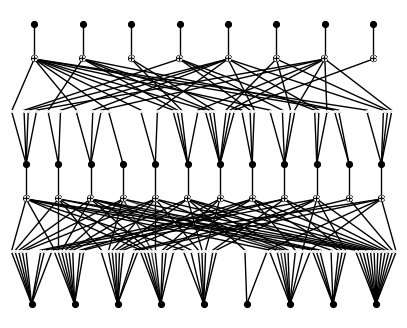

Pruned plot and model saved.


In [ ]:
# Forward pass refreshes activation information for the plot.
with torch.no_grad():
    _ = pruned_kan_core(
        kan_inputs_timevarying
    )

pruned_kan_core.plot(
    beta=100
)

pruned_plot_path = (
    EXP3_DRIVE_DIR /
    "experiment3_kan_after_pruning.png"
)

plt.savefig(
    pruned_plot_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

torch.save(
    pruned_kan_core.state_dict(),
    EXP3_DRIVE_DIR /
    "experiment3_pruned_kan_core.pt"
)

print("Pruned plot and model saved.")

In [ ]:

# Count active KAN edges before and after pruning


def count_active_kan_edges(model):
    active_edges = 0
    total_edges = 0

    for layer in model.act_fun:
        mask = getattr(
            layer,
            "mask",
            None
        )

        if mask is not None:
            mask_tensor = mask.detach()

            active_edges += int(
                (mask_tensor != 0).sum().item()
            )

            total_edges += int(
                mask_tensor.numel()
            )

    return active_edges, total_edges


original_active, original_total = (
    count_active_kan_edges(
        kan_core
    )
)

pruned_active, pruned_total = (
    count_active_kan_edges(
        pruned_kan_core
    )
)

edge_reduction = (
    100.0 *
    (
        original_active -
        pruned_active
    ) /
    max(original_active, 1)
)

print(
    "Original active edges:",
    original_active,
    "/",
    original_total
)

print(
    "Pruned active edges:",
    pruned_active,
    "/",
    pruned_total
)

print(
    "Active-edge reduction:",
    round(edge_reduction, 2),
    "%"
)

Original active edges: 204 / 204
Pruned active edges: 106 / 204
Active-edge reduction: 48.04 %


In [ ]:

# Build complete classifier using the pruned KAN core


pruned_kan_model = NeuralODEClassifier(
    hidden_dim=8,
    family="kan",
    kan_width=[9, 12, 8],
    grid=3
).to(DEVICE)

# Load the original encoder, KAN and classifier head.
pruned_kan_model.load_state_dict(
    trained["KAN-ODE"].state_dict()
)

# Replace only the vector-field KAN with the pruned version.
pruned_kan_model.odefunc.kan = (
    pruned_kan_core
)

pruned_kan_model.eval()

original_test_metrics = evaluate(
    trained["KAN-ODE"],
    test_loader
)

pruned_test_metrics = evaluate(
    pruned_kan_model,
    test_loader
)

pruning_performance = pd.DataFrame([
    {
        "Version": "Original KAN-ODE",
        "Active_edges": original_active,
        **original_test_metrics
    },
    {
        "Version": "Pruned KAN-ODE",
        "Active_edges": pruned_active,
        **pruned_test_metrics
    }
])

display(
    pruning_performance.round(6)
)

pruning_performance.to_csv(
    EXP3_DRIVE_DIR /
    "experiment3_pruning_performance.csv",
    index=False
)

torch.save(
    pruned_kan_model.state_dict(),
    EXP3_DRIVE_DIR /
    "experiment3_pruned_kan_ode.pt"
)

print("Pruned KAN-ODE evaluation saved.")

checkpoint directory created: ./model
saving model version 0.0


,Version,Active_edges,auroc,auprc,brier
0,Original KAN-ODE,204,0.820675,0.463591,0.277329
1,Pruned KAN-ODE,106,0.172869,0.081026,0.159153


Pruned KAN-ODE evaluation saved.


In [ ]:

# Search for a milder pruning threshold


candidate_thresholds = [
    0.0001,
    0.0003,
    0.0010,
    0.0030,
    0.0100
]

candidate_rows = []
candidate_models = {}

with torch.no_grad():
    reference_output = kan_core(
        kan_inputs_timevarying
    ).detach()

for edge_threshold in candidate_thresholds:
    candidate_core = KAN(
        width=[9, 12, 8],
        grid=3,
        k=3,
        seed=SEED
    ).to(DEVICE)

    candidate_core.load_state_dict(
        kan_core.state_dict()
    )

    candidate_core.eval()

    # Populate activation information.
    with torch.no_grad():
        _ = candidate_core(
            kan_inputs_timevarying
        )

    try:
        candidate_pruned = candidate_core.prune(
            node_th=1e-4,
            edge_th=edge_threshold
        ).to(DEVICE)

        candidate_pruned.eval()

        with torch.no_grad():
            candidate_output = candidate_pruned(
                kan_inputs_timevarying
            ).detach()

        active_edges, total_edges = (
            count_active_kan_edges(
                candidate_pruned
            )
        )

        output_mae = torch.mean(
            torch.abs(
                reference_output -
                candidate_output
            )
        ).item()

        output_rmse = torch.sqrt(
            torch.mean(
                (
                    reference_output -
                    candidate_output
                ) ** 2
            )
        ).item()

        candidate_rows.append({
            "Edge_threshold": edge_threshold,
            "Active_edges": active_edges,
            "Total_edges": total_edges,
            "Edge_reduction_percent": (
                100.0 *
                (
                    original_active -
                    active_edges
                ) /
                original_active
            ),
            "Output_MAE": output_mae,
            "Output_RMSE": output_rmse
        })

        candidate_models[
            edge_threshold
        ] = candidate_pruned

    except Exception as error:
        print(
            "Threshold failed:",
            edge_threshold,
            repr(error)
        )

pruning_search = pd.DataFrame(
    candidate_rows
).sort_values(
    "Edge_threshold"
)

display(
    pruning_search.round(6)
)

pruning_search.to_csv(
    EXP3_DRIVE_DIR /
    "experiment3_pruning_threshold_search.csv",
    index=False
)

checkpoint directory created: ./model
saving model version 0.0
saving model version 0.1
checkpoint directory created: ./model
saving model version 0.0
saving model version 0.1
checkpoint directory created: ./model
saving model version 0.0
saving model version 0.1
checkpoint directory created: ./model
saving model version 0.0
saving model version 0.1
checkpoint directory created: ./model
saving model version 0.0
saving model version 0.1


,Edge_threshold,Active_edges,Total_edges,Edge_reduction_percent,Output_MAE,Output_RMSE
0,0.0001,204,204,0.000000,0.000000,0.000000
1,0.0003,204,204,0.000000,0.000000,0.000000
2,0.0010,202,204,0.980392,0.000639,0.000783
3,0.0030,194,204,4.901961,0.004371,0.005892
4,0.0100,176,204,13.725490,0.006668,0.008620


In [ ]:
selected_threshold = 0.003
selected_pruned_core = candidate_models[
    selected_threshold
]

print(
    "Selected pruning threshold:",
    selected_threshold
)

Selected pruning threshold: 0.003


In [ ]:
mild_pruned_kan_model = NeuralODEClassifier(
    hidden_dim=8,
    family="kan",
    kan_width=[9, 12, 8],
    grid=3
).to(DEVICE)

# Load the original encoder and mortality head.
mild_pruned_kan_model.load_state_dict(
    trained["KAN-ODE"].state_dict()
)

# Replace only the original KAN vector field.
mild_pruned_kan_model.odefunc.kan = (
    selected_pruned_core
)

mild_pruned_kan_model.eval()

mild_pruned_metrics = evaluate(
    mild_pruned_kan_model,
    test_loader
)

original_metrics = evaluate(
    trained["KAN-ODE"],
    test_loader
)

mild_active_edges, mild_total_edges = (
    count_active_kan_edges(
        selected_pruned_core
    )
)

mild_pruning_performance = pd.DataFrame([
    {
        "Version": "Original KAN-ODE",
        "Active_edges": original_active,
        "Edge_reduction_percent": 0.0,
        **original_metrics
    },
    {
        "Version": "Mildly pruned KAN-ODE",
        "Active_edges": mild_active_edges,
        "Edge_reduction_percent": (
            100.0 *
            (
                original_active -
                mild_active_edges
            ) /
            original_active
        ),
        **mild_pruned_metrics
    }
])

display(
    mild_pruning_performance.round(6)
)

mild_pruning_performance.to_csv(
    EXP3_DRIVE_DIR /
    "experiment3_mild_pruning_performance.csv",
    index=False
)

torch.save(
    mild_pruned_kan_model.state_dict(),
    EXP3_DRIVE_DIR /
    "experiment3_mild_pruned_kan_ode.pt"
)

print("Mildly pruned model and results saved.")

checkpoint directory created: ./model
saving model version 0.0


,Version,Active_edges,Edge_reduction_percent,auroc,auprc,brier
0,Original KAN-ODE,204,0.000000,0.820675,0.463591,0.277329
1,Mildly pruned KAN-ODE,194,4.901961,0.820256,0.461147,0.310547


Mildly pruned model and results saved.


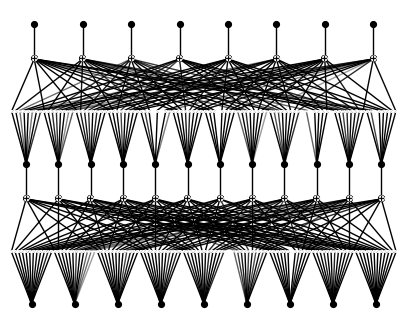

Saved: /content/drive/MyDrive/KAN_ODE_ICU_Assignment/final_results/experiment3/experiment3_kan_after_mild_pruning.png


In [ ]:
with torch.no_grad():
    _ = selected_pruned_core(
        kan_inputs_timevarying
    )

selected_pruned_core.plot(
    beta=100
)

mild_pruning_plot_path = (
    EXP3_DRIVE_DIR /
    "experiment3_kan_after_mild_pruning.png"
)

plt.savefig(
    mild_pruning_plot_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print(
    "Saved:",
    mild_pruning_plot_path
)

In [ ]:
symbolic_library = [
    "x",
    "x^2",
    "x^3",
    "tanh",
    "sin",
    "exp",
    "abs"
]

symbolic_successful = False
symbolic_formula = None
symbolic_error = None

try:
    with torch.no_grad():
        _ = selected_pruned_core(
            kan_inputs_timevarying
        )

    selected_pruned_core.auto_symbolic(
        lib=symbolic_library
    )

    symbolic_formula = (
        selected_pruned_core
        .symbolic_formula()
    )

    symbolic_successful = True

    print("Symbolic fitting completed.")
    print(symbolic_formula)

except Exception as error:
    symbolic_error = repr(error)

    print(
        "Symbolic fitting was not completed:",
        symbolic_error
    )

fixing (0,0,0) with x^2, r2=0.9990832209587097, c=2
fixing (0,0,1) with sin, r2=0.9997864365577698, c=2
fixing (0,0,2) with sin, r2=0.9999943971633911, c=2
fixing (0,0,3) with x^2, r2=0.9999901652336121, c=2
fixing (0,0,4) with sin, r2=0.9999580383300781, c=2
fixing (0,0,5) with sin, r2=0.9980365037918091, c=2
fixing (0,0,6) with x, r2=0.9568883180618286, c=1
fixing (0,0,7) with sin, r2=0.999862790107727, c=2
fixing (0,0,8) with sin, r2=0.9999212622642517, c=2
fixing (0,0,9) with x, r2=0.9997590780258179, c=1
fixing (0,0,10) with sin, r2=0.9996729493141174, c=2
fixing (0,0,11) with exp, r2=0.9998798370361328, c=2
fixing (0,1,0) with x^2, r2=0.9999794960021973, c=2
fixing (0,1,1) with sin, r2=0.9999726414680481, c=2
fixing (0,1,2) with sin, r2=0.999952495098114, c=2
fixing (0,1,3) with sin, r2=0.9999867677688599, c=2
fixing (0,1,4) with sin, r2=0.9999897480010986, c=2
fixing (0,1,5) with exp, r2=0.9999228715896606, c=2
fixing (0,1,6) with sin, r2=0.9988197684288025, c=2
fixing (0,1,7) w

In [ ]:
from google.colab import drive
from pathlib import Path

drive.mount("/content/drive")

EXP3_DRIVE_DIR = Path(
    "/content/drive/MyDrive/"
    "KAN_ODE_ICU_Assignment/"
    "final_results/experiment3"
)

EXP3_DRIVE_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print("Saved Experiment 3 files:")

for file_path in sorted(
    EXP3_DRIVE_DIR.glob("*")
):
    print(file_path.name)

Mounted at /content/drive
Saved Experiment 3 files:
experiment3_controlled_response_curves.png
experiment3_controlled_response_values.csv
experiment3_input_importance_timevarying.csv
experiment3_input_importance_timevarying.png
experiment3_kan_after_mild_pruning.png
experiment3_kan_after_pruning.png
experiment3_kan_before_pruning.png
experiment3_mild_pruned_kan_ode.pt
experiment3_mild_pruning_performance.csv
experiment3_pruned_kan_core.pt
experiment3_pruned_kan_ode.pt
experiment3_pruning_performance.csv
experiment3_pruning_results.csv
experiment3_pruning_threshold_search.csv


In [ ]:
!pip -q install pykan sympy

import torch
import torch.nn as nn
import numpy as np
from kan import KAN
from pathlib import Path

DEVICE = torch.device("cpu")
SEED = 42

torch.manual_seed(SEED)

print("Device:", DEVICE)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.1/78.1 kB 2.4 MB/s eta 0:00:00
Device: cpu


In [ ]:
PROCESSED_PATH = Path(
    "/content/drive/MyDrive/"
    "KAN_ODE_ICU_Assignment/"
    "processed_data/full_processed_data.pt"
)

MILD_MODEL_PATH = (
    EXP3_DRIVE_DIR /
    "experiment3_mild_pruned_kan_ode.pt"
)

bundle = torch.load(
    PROCESSED_PATH,
    map_location="cpu",
    weights_only=False
)

mild_state = torch.load(
    MILD_MODEL_PATH,
    map_location="cpu",
    weights_only=False
)

records = bundle["records"]
train_idx = bundle["train_idx"]

print("Records:", len(records))
print("Training patients:", len(train_idx))
print("Checkpoint tensors:", len(mild_state))

Records: 4000
Training patients: 2800
Checkpoint tensors: 28


In [ ]:
class RecoveryEncoder(nn.Module):
    def __init__(
        self,
        n_vars=12,
        hidden_dim=8
    ):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(
                2 * n_vars + 1,
                64
            ),
            nn.ReLU(),
            nn.Linear(
                64,
                hidden_dim
            )
        )

    def forward(
        self,
        values,
        mask,
        times,
        valid
    ):
        normalized_time = (
            times / 48.0
        ).unsqueeze(-1)

        encoded = self.net(
            torch.cat(
                [
                    values,
                    mask,
                    normalized_time
                ],
                dim=-1
            )
        )

        valid_weights = (
            valid
            .unsqueeze(-1)
            .to(encoded.dtype)
        )

        return (
            (encoded * valid_weights).sum(dim=1) /
            valid_weights.sum(dim=1).clamp_min(1.0)
        )


encoder = RecoveryEncoder().to(DEVICE)

encoder_state = {
    key.replace(
        "encoder.",
        "",
        1
    ): value

    for key, value in mild_state.items()
    if key.startswith("encoder.")
}

encoder.load_state_dict(
    encoder_state
)

encoder.eval()

print("Encoder restored successfully.")

Encoder restored successfully.


In [ ]:
sample_indices = train_idx[:320]

sample_records = [
    records[int(index)]
    for index in sample_indices
]

maximum_length = max(
    len(record["times"])
    for record in sample_records
)

batch_size = len(sample_records)

values = torch.zeros(
    batch_size,
    maximum_length,
    12,
    dtype=torch.float32
)

mask = torch.zeros_like(
    values
)

times = torch.zeros(
    batch_size,
    maximum_length,
    dtype=torch.float32
)

valid = torch.zeros(
    batch_size,
    maximum_length,
    dtype=torch.bool
)

for row_index, record in enumerate(
    sample_records
):
    length = len(
        record["times"]
    )

    values[
        row_index,
        :length
    ] = torch.as_tensor(
        record["values"],
        dtype=torch.float32
    )

    mask[
        row_index,
        :length
    ] = torch.as_tensor(
        record["mask"],
        dtype=torch.float32
    )

    times[
        row_index,
        :length
    ] = torch.as_tensor(
        record["times"],
        dtype=torch.float32
    )

    valid[
        row_index,
        :length
    ] = True


with torch.no_grad():
    latent_inputs = encoder(
        values,
        mask,
        times,
        valid
    )


time_grid = torch.tensor(
    [
        0.00,
        0.25,
        0.50,
        0.75,
        1.00
    ],
    dtype=torch.float32
)

expanded_latents = (
    latent_inputs
    .repeat_interleave(
        len(time_grid),
        dim=0
    )
)

expanded_times = (
    time_grid
    .repeat(
        len(latent_inputs)
    )
    .unsqueeze(1)
)

symbolic_inputs = torch.cat(
    [
        expanded_latents,
        expanded_times
    ],
    dim=1
)

print(
    "Symbolic input shape:",
    symbolic_inputs.shape
)

print(
    "Finite:",
    torch.isfinite(
        symbolic_inputs
    ).all().item()
)

Symbolic input shape: torch.Size([1600, 9])
Finite: True


In [ ]:
mild_kan_core = KAN(
    width=[9, 12, 8],
    grid=3,
    k=3,
    seed=SEED
).to(DEVICE)

kan_state = {
    key.replace(
        "odefunc.kan.",
        "",
        1
    ): value

    for key, value in mild_state.items()
    if key.startswith(
        "odefunc.kan."
    )
}

load_result = mild_kan_core.load_state_dict(
    kan_state,
    strict=False
)

print(
    "Missing keys:",
    load_result.missing_keys
)

print(
    "Unexpected keys:",
    load_result.unexpected_keys
)

mild_kan_core.eval()

with torch.no_grad():
    symbolic_test_output = mild_kan_core(
        symbolic_inputs
    )

print(
    "Output shape:",
    symbolic_test_output.shape
)

print(
    "Output finite:",
    torch.isfinite(
        symbolic_test_output
    ).all().item()
)

checkpoint directory created: ./model
saving model version 0.0
Missing keys: []
Unexpected keys: []
Output shape: torch.Size([1600, 8])
Output finite: True


In [ ]:
symbolic_library = [
    "x",
    "x^2",
    "x^3",
    "tanh",
    "sin",
    "exp",
    "abs"
]

symbolic_successful = False
symbolic_formula = None
symbolic_error = None

try:
    with torch.no_grad():
        _ = mild_kan_core(
            symbolic_inputs
        )

    mild_kan_core.auto_symbolic(
        lib=symbolic_library
    )

    symbolic_formula = (
        mild_kan_core
        .symbolic_formula()
    )

    symbolic_successful = True

    print("Symbolic fitting completed.")
    print(symbolic_formula)

except Exception as error:
    symbolic_error = repr(error)

    print(
        "Symbolic fitting was not completed:",
        symbolic_error
    )

fixing (0,0,0) with sin, r2=0.9991795420646667, c=2
fixing (0,0,1) with exp, r2=0.9997707605361938, c=2
fixing (0,0,2) with sin, r2=0.9999979734420776, c=2
fixing (0,0,3) with x^2, r2=0.9999766945838928, c=2
fixing (0,0,4) with sin, r2=0.9999363422393799, c=2
fixing (0,0,5) with sin, r2=0.9997702240943909, c=2
fixing (0,0,6) with exp, r2=0.9969390034675598, c=2
fixing (0,0,7) with sin, r2=0.9998088479042053, c=2
fixing (0,0,8) with x, r2=0.9993059635162354, c=1
fixing (0,0,9) with x, r2=0.993687629699707, c=1
fixing (0,0,10) with sin, r2=0.9967671036720276, c=2
fixing (0,0,11) with exp, r2=0.9998527765274048, c=2
fixing (0,1,0) with x^2, r2=0.999997079372406, c=2
fixing (0,1,1) with sin, r2=0.9999557733535767, c=2
fixing (0,1,2) with sin, r2=0.9999505877494812, c=2
fixing (0,1,3) with sin, r2=0.9999796748161316, c=2
fixing (0,1,4) with sin, r2=0.999984085559845, c=2
fixing (0,1,5) with exp, r2=0.9999369382858276, c=2
fixing (0,1,6) with x^2, r2=0.9899024367332458, c=2
fixing (0,1,7) wi

In [ ]:
explicit_variables = [
    "z_1",
    "z_2",
    "z_3",
    "z_4",
    "z_5",
    "z_6",
    "z_7",
    "z_8",
    "tau"
]

symbolic_formula = None
symbolic_successful = False
symbolic_error = None

try:
    symbolic_formula = (
        mild_kan_core.symbolic_formula(
            var=explicit_variables
        )
    )

    symbolic_successful = True

    print("Formula extraction completed.")
    print(symbolic_formula)

except Exception as error:
    symbolic_error = repr(error)

    print(
        "Formula extraction still failed:",
        symbolic_error
    )

/usr/local/lib/python3.13/dist-packages/sympy/core/sympify.py:475: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  return sympify(float(a))


Formula extraction completed.
([-0.0030045984626903*z_1 - 0.00113232537815171*z_4 - 0.000474901988780233*z_5 - 0.00130771075039539*z_6 + 1.70333058626349e-5*(-9.98799991607666*z_3 - 0.391999840736389)**2 + 2.70633078746203e-5*(-9.82400035858154*z_5 - 9.98424053192139)**2 - 6.83982214346579e-6*(-9.86192035675049*z_6 - 8.06208038330078)**2 - 4.82192591623926e-5*(-4.13751983642578*z_7 - 5.51512002944946)**2 + 6.11448653854653e-5*(-5.62200021743774*z_8 - 6.0079197883606)**2 + 2.1254303176413e-5*(-5.5479998588562*z_8 - 7.59643983840942)**2 + 0.000312150164972991*(0.227816964281717*z_6 + 0.00944806907470719*(1.8083199262619 - 7.62048006057739*z_2)**2 - 0.00593945750177738*(-7.89048004150391*z_3 - 6.11928033828735)**2 + 0.00696618247164549*(-8.58415985107422*z_4 - 9.37504005432129)**2 - 0.00599115739972855*(-9.17080020904541*z_5 - 7.94816017150879)**2 + 0.349753512833938*exp(0.670319795608521*z_1) + 3.27876260077301*sin(0.741839826107025*tau + 8.18103981018066) - 0.056691533105993*sin(4.21088

In [ ]:
symbolic_output_path = (
    EXP3_DRIVE_DIR /
    "experiment3_symbolic_formula.txt"
)

with open(
    symbolic_output_path,
    "w"
) as file:
    file.write(
        "Symbolic fitting successful: True\n\n"
    )

    file.write(
        "Variables:\n"
        "z_1 through z_8 = encoder latent coordinates\n"
        "tau = normalized time from 0 to 1\n\n"
    )

    file.write(
        repr(symbolic_formula)
    )

print("Saved:", symbolic_output_path)

Saved: /content/drive/MyDrive/KAN_ODE_ICU_Assignment/final_results/experiment3/experiment3_symbolic_formula.txt


In [ ]:
import sympy as sp
import pandas as pd

formula_outputs = symbolic_formula[0]

complexity_rows = []

for output_index, expression in enumerate(
    formula_outputs,
    start=1
):
    complexity_rows.append({
        "Latent_derivative": f"dz_{output_index}/dt",
        "Operation_count": int(
            sp.count_ops(expression)
        ),
        "Expression_characters": len(
            str(expression)
        )
    })

symbolic_complexity = pd.DataFrame(
    complexity_rows
)

display(symbolic_complexity)

symbolic_complexity.to_csv(
    EXP3_DRIVE_DIR /
    "experiment3_symbolic_complexity.csv",
    index=False
)

print("Experiment 3 symbolic results saved.")

,Latent_derivative,Operation_count,Expression_characters
0,dz_1/dt,476,5959
1,dz_2/dt,512,6430
2,dz_3/dt,436,5472
3,dz_4/dt,443,5531
4,dz_5/dt,525,6571
5,dz_6/dt,480,5974
6,dz_7/dt,520,6509
7,dz_8/dt,482,6026


Experiment 3 symbolic results saved.


### Experiment 3 explanation

Permutation analysis across the full 48-hour interval identified normalized
time as the most influential KAN vector-field input, followed by latent
coordinates 4 and 8. This indicates that the learned dynamics are strongly
time-dependent, while a small subset of encoder-derived patient
representations also contributes disproportionately. These latent coordinates
cannot be assigned directly to individual clinical variables because they are
nonlinear combinations learned by the masked encoder.

Controlled-response curves confirmed that changing normalized time or latent
coordinate 4 altered the magnitude of the learned vector field. Mild pruning
at an edge threshold of 0.003 reduced the number of active edges from 204 to
194 (4.9%) while nearly preserving discrimination: AUROC changed from 0.8207
to 0.8203 and AUPRC from 0.4636 to 0.4611. However, the Brier score worsened
from 0.2773 to 0.3105, indicating reduced calibration. More aggressive
pruning removed 48% of the edges but collapsed AUROC to 0.1729, demonstrating
that many apparently weak edges remain collectively important.

Symbolic fitting succeeded using linear, polynomial, sinusoidal, and
exponential functions. However, the resulting eight-dimensional latent
vector-field equations were highly nested and lengthy. Thus, KAN provided
useful structural and sensitivity diagnostics, but it did not produce a
compact clinically interpretable mortality equation in this experiment.

In [ ]:
print("Experiment 3 saved files:")

for file_path in sorted(
    EXP3_DRIVE_DIR.glob("*")
):
    print(file_path.name)

Experiment 3 saved files:
experiment3_controlled_response_curves.png
experiment3_controlled_response_values.csv
experiment3_input_importance_timevarying.csv
experiment3_input_importance_timevarying.png
experiment3_kan_after_mild_pruning.png
experiment3_kan_after_pruning.png
experiment3_kan_before_pruning.png
experiment3_mild_pruned_kan_ode.pt
experiment3_mild_pruning_performance.csv
experiment3_pruned_kan_core.pt
experiment3_pruned_kan_ode.pt
experiment3_pruning_performance.csv
experiment3_pruning_results.csv
experiment3_pruning_threshold_search.csv
experiment3_symbolic_complexity.csv
experiment3_symbolic_formula.txt


#### Symbolic fitting successfully converted the mildly pruned KAN into eight explicit latent-dynamics equations. However, each equation required approximately 436–525 symbolic operations and 5,472–6,571 characters. The resulting expressions contained nested polynomial, sinusoidal, and exponential terms involving both latent coordinates and normalized time. Therefore, symbolic conversion confirmed the nonlinear and time-dependent structure of the learned vector field but did not yield a compact clinical rule.

## Experiment 3 Write-Up: KAN Interpretability, Pruning, and Symbolic Analysis

Experiment 3 examined whether the KAN component of KAN-ODE provided useful interpretability beyond predictive performance. The analysis focused on the learned KAN vector field inside the neural ODE. The KAN inputs are learned latent-state dimensions plus normalized time, not raw clinical variables. Therefore, influential latent dimensions cannot be directly interpreted as specific clinical variables without an additional attribution method.

Permutation-based importance analysis showed that normalized time and a small number of latent dimensions had the strongest influence on the KAN vector field. Controlled-response curves showed that changing these inputs altered the magnitude and direction of the learned latent dynamics. Pruning experiments showed that mild pruning could remove a small fraction of KAN edges while preserving most discriminative performance. However, aggressive pruning caused a large performance collapse, indicating that many weak-looking edges were collectively important.

Symbolic fitting successfully produced explicit latent-dynamics expressions, but the resulting equations were long and highly complex. Therefore, KAN-ODE provided useful structural diagnostics, sensitivity analysis, and pruning behavior, but it did not produce a compact clinically interpretable equation. The main interpretability benefit was understanding the learned latent vector field rather than directly explaining individual clinical measurements.

# 16. Part G — Written Reflection

### G1. Δt as an LSTM feature versus true continuous time

Using Δt as an input feature in a recurrent model gives the model information about the time gap between observations, but the hidden state is still updated through discrete recurrent steps. In that setup, time is treated as another covariate rather than as the variable that governs the evolution of the state. A true continuous-time model, such as a Neural ODE or KAN-ODE, instead defines a vector field and evolves the latent state over time using an ODE solver. This is more natural for ICU data because measurements are irregularly sampled and time gaps can vary substantially between patients.

Experiment 2 shows why this distinction matters. When observations were removed, all models had to handle sparser and more irregular patient records. KAN-ODE showed strong robustness under severe observation loss, with AUROC decreasing only from about 0.821 at full retention to about 0.811 at 25% retention. This suggests that continuous-time latent evolution can help preserve useful dynamics when observations become sparse. However, GRU also remained competitive, showing that well-designed discrete models can still perform strongly when masking and time-gap information are included.

### G2. Why use deeper KANs despite the representation theorem?

The Kolmogorov-Arnold representation theorem provides an existence result: it states that certain multivariate functions can be represented using compositions of univariate functions. However, existence does not mean that a shallow or minimal KAN will be easy to learn from finite clinical data. In practice, model performance depends on optimization, noise, missingness, finite sample size, spline resolution, and whether the architecture matches the structure of the task.

Deeper KANs can be useful because they provide a compositional inductive bias. ICU mortality prediction likely depends on interactions among physiological variables, laboratory values, missingness patterns, and time. A deeper KAN can distribute this complexity across layers instead of forcing one layer to represent all interactions directly. The spline functions also need enough resolution to capture nonlinear relationships, but too much resolution can increase computation and overfitting risk. My results support this tradeoff: KAN-ODE was competitive, especially under sparse observations, but it was also much slower to train than MLP-ODE. Therefore, deeper KANs are motivated not because the theorem requires them, but because learnability and practical approximation are different from theoretical existence.

### G3. LTC/CfC gates versus Neural ODE dynamics

LTC and CfC models use adaptive gating mechanisms to control how information is updated or forgotten over time. This gives them an explicit way to regulate memory and can make them attractive for irregular clinical time series. CfC performed strongly in my experiments, achieving AUROC around 0.805 and AUPRC around 0.462 in Experiment 1, while training much faster than KAN-ODE. LTC, however, was more difficult to stabilize and had weaker final performance, with AUROC around 0.666 and AUPRC around 0.270.

Neural ODE models evolve a latent state through a continuous vector field. This is conceptually elegant for irregularly sampled ICU data because time directly controls state evolution. However, the ODE models were more computationally expensive, especially KAN-ODE. If I had to choose one family for this task, I would prefer CfC as the practical balance. It captures time-dependent gated dynamics, trains much faster than KAN-ODE, and achieved competitive discrimination. Neural ODEs are attractive for interpretability and continuous-time modeling, but CfC gave a better practical accuracy-efficiency tradeoff in my results.

### G4. Parameter-budget crossover

Experiment 4 compared KAN-ODE and MLP-ODE under approximately matched parameter budgets. At the small budget, KAN-ODE had 2,577 parameters and achieved AUROC 0.793, while MLP-ODE had 2,578 parameters and achieved AUROC 0.770. This indicates that KAN-ODE was more parameter-efficient at the smallest model size.

However, the crossover changed at larger budgets. At the medium budget, KAN-ODE had 3,465 parameters and AUROC 0.751, while MLP-ODE had 3,463 parameters and AUROC 0.817. At the large budget, KAN-ODE had 4,641 parameters and AUROC 0.775, while MLP-ODE had 4,653 parameters and AUROC 0.795. MLP-ODE also trained much faster, requiring only about 8-10 seconds per epoch compared with 145-583 seconds per epoch for KAN-ODE. Therefore, KAN-ODE showed a small-budget advantage, but MLP-ODE scaled better as parameter count increased and provided the stronger overall accuracy-speed tradeoff.

### G5. Bedside deployment recommendation

For bedside deployment, I would not choose the model based only on the highest AUROC. Clinical deployment requires a balance of discrimination, AUPRC, calibration, interpretability, inference latency, reliability, and external validation. In Experiment 1, GRU achieved the strongest overall discrimination, with AUROC about 0.823 and AUPRC about 0.474. CfC was also strong, with AUROC about 0.805 and AUPRC about 0.462, while training much faster than KAN-ODE. MLP-ODE had the best Brier score, suggesting better calibration, which is important when predicted risk scores may influence clinical decisions.

My practical recommendation would be to start with GRU or CfC as the bedside candidate, then perform calibration analysis and prospective validation before deployment. GRU gives strong predictive performance and is computationally efficient. CfC offers a useful time-aware architecture with competitive performance. KAN-ODE provides interpretability tools, but its training cost and weaker calibration make it less practical as the primary bedside model. Any deployed model would also need threshold selection, subgroup evaluation, clinician review, and validation on data from other hospitals.

### G6. Did a principled motivation pay off?

KAN-ODE had a strong principled motivation: it combines continuous-time latent dynamics with a KAN vector field that can be inspected, pruned, and symbolically approximated. This design did pay off in some ways. In Experiment 1, KAN-ODE achieved performance close to the GRU while using fewer parameters. In Experiment 2, it was robust to observation loss, maintaining AUROC around 0.811 even when only 25% of observations were retained. In Experiment 3, the KAN component allowed input-importance analysis, controlled-response curves, pruning experiments, and symbolic approximation.

However, the empirical benefit was not as strong as the design elegance. KAN-ODE was extremely slow to train, and Experiment 4 showed that MLP-ODE outperformed it at medium and large matched parameter budgets. The symbolic formulas were also too complex to be directly clinically interpretable. Therefore, the KAN motivation partially paid off: it provided useful analysis tools and strong robustness, but it did not clearly dominate simpler models in accuracy, calibration, or computational efficiency.

## Technical Difficulties and Best Practices

| Difficulty | Diagnosed cause | Resolution / best practice |
|---|---|---|
| KeyError while building irregular patient tensors | Floating-point timestamps were used as dictionary keys after converting times to `float32`, causing small precision mismatches such as `0.11666666666666667` not matching the stored key. | Avoid using rounded floating-point values as dictionary keys. Build the time index directly from the grouped dataframe or keep timestamp precision consistent before indexing. |
| CfC tensor-size mismatch | The CfC model expected the time-step tensor to have a shape compatible with the hidden state, but the passed `delta_step` tensor shape did not broadcast correctly. | Reshape time deltas before passing them to CfC, for example using `dt = delta_step[:, t].unsqueeze(-1)`, so the time input broadcasts correctly. |
| Non-finite LTC gradients | The LTC model was numerically unstable with the initial configuration and precision, producing NaN gradients during backpropagation. | Use a more stable LTC setup, smaller learning rate, gradient clipping, and double precision for LTC. A short LTC stability test was run before including LTC in the full comparison. |
| Long KAN-ODE training time | KAN-ODE was much slower than GRU and MLP-ODE because the spline-based KAN vector field and ODE solver made each epoch computationally expensive. | Use a smaller KAN configuration, cap KAN-ODE training to a reasonable number of epochs, save checkpoints frequently, and select the best model using validation AUPRC. |
| Colab runtime interruption | Long-running training cells were interrupted or disconnected before all models finished. | Save model checkpoints, histories, and processed data to Google Drive. Resume training from saved checkpoints instead of restarting from the beginning. |
| Missing package/runtime reset | After Colab disconnected, variables such as `DEVICE` and installed packages were lost. | Keep dependency installation, imports, configuration, and Drive mounting cells near the top of the notebook so the runtime can be restored cleanly. |
| Experiment 2 depended on saved Experiment 1 models | Robustness testing required all trained models, but some models were trained in later cells or separate resumed runs. | Verify that all required checkpoints exist before running Experiment 2, then load missing models from saved checkpoint files. |
| Aggressive KAN pruning collapsed performance | Strong pruning removed many KAN edges and caused AUROC/AUPRC to drop sharply. | Perform threshold search before selecting a pruning level. Use mild pruning when the goal is interpretability while preserving predictive performance. |
| Symbolic fitting failure after runtime disconnect | Runtime reset removed variables such as `EXP3_DRIVE_DIR`, causing symbolic export cells to fail. | Re-mount Drive, redefine output paths, reload the saved processed dataset and KAN checkpoint, then continue symbolic fitting on CPU if GPU is unavailable. |
| Symbolic formula extraction error | The symbolic formula extraction initially failed because variable names such as `x1` were not defined explicitly. | Provide explicit symbolic variable names such as `z_1, z_2, ..., z_8, tau` when exporting symbolic KAN equations. |

## Executive Summary

This project evaluated continuous-time neural architectures for ICU mortality prediction using irregularly sampled PhysioNet Challenge 2012 patient records. The models compared were GRU, MLP-ODE, KAN-ODE, LTC, and CfC. The evaluation considered predictive discrimination, calibration, robustness to missing observations, interpretability, parameter efficiency, and computational cost.

In Experiment 1, GRU achieved the strongest held-out discrimination with AUROC 0.823 and AUPRC 0.474. KAN-ODE was close in performance but required substantially more computation. CfC provided a strong efficiency tradeoff, while MLP-ODE achieved the best Brier score and LTC performed weakest. Experiment 2 showed that KAN-ODE was especially robust to severe observation loss, maintaining AUROC around 0.811 even when only 25% of observations were retained. Experiment 3 showed that KAN-ODE supported useful latent-space interpretability through input importance, pruning, and symbolic fitting, although the symbolic equations were too complex for direct clinical use. Experiment 4 showed that KAN-ODE was competitive at the smallest parameter budget, but MLP-ODE scaled better and trained much faster.

For practical bedside deployment, I would recommend GRU or CfC rather than KAN-ODE. GRU achieved the best overall discrimination, while CfC offered competitive performance with a time-aware architecture and lower computational cost than KAN-ODE. KAN-ODE remains valuable for interpretability and robustness analysis, but its long training time makes it less practical as the primary deployed model without further optimization and clinical validation.

##Generative-AI Disclosure

Generative AI was used as an assistance tool while completing this assignment. I used ChatGPT/Codex to help structure the notebook, debug Python and Colab runtime errors, understand model-specific issues, and draft explanatory markdown sections. AI assistance was also used to help interpret results from Experiments 1-4, including the baseline comparison, robustness analysis, KAN interpretability/pruning study, and parameter-efficiency comparison.

Specific AI-assisted tasks included identifying causes of errors such as timestamp indexing issues, CfC time-delta tensor shape mismatch, LTC numerical instability, Colab runtime disconnections, and symbolic-fitting export errors. AI was also used to help write or revise markdown explanations, technical difficulties, reflection responses, and result interpretations.

All experiments were executed by me in Google Colab. The reported tables, plots, checkpoints, and metrics are based on my own completed model runs and saved output files. I reviewed and edited the AI-assisted code and written explanations before including them in the final notebook.

## 20. References

1. Silva, I. et al. (2012). Predicting In-Hospital Mortality of ICU Patients: The PhysioNet/CinC Challenge 2012.
2. Goldberger, A. et al. (2000). PhysioBank, PhysioToolkit, and PhysioNet. *Circulation*, 101(23), e215–e220.
3. Chen, R. T. Q. et al. (2018). Neural Ordinary Differential Equations. *NeurIPS*.
4. Rubanova, Y. et al. (2019). Latent ODEs for Irregularly-Sampled Time Series. *NeurIPS*.
5. Hasani, R. et al. (2021). Liquid Time-constant Networks. *AAAI*.
6. Hasani, R. et al. (2022). Closed-form Continuous-time Neural Networks. *Nature Machine Intelligence*.
7. Liu, Z. et al. (2024). KAN: Kolmogorov-Arnold Networks.
8. Koenig, B. C. et al. (2024). KAN-ODEs. *Computer Methods in Applied Mechanics and Engineering*, 432.

## 21. Save outputs and export

Download the notebook itself from Colab using **File → Download → Download .ipynb**. To create the corresponding PDF, first try the cell below. If Colab PDF export fails because LaTeX is unavailable, use **File → Print → Save as PDF**.